# Intern Task 1: Dataset Understanding, Edit Analysis and Strategy Readiness

## Role of this notebook

This is the **student version** of Stage 1. Its code cells are intentionally
empty. You must write, run and explain the analysis yourself.

Stage 1 establishes whether the multilingual simplification data are valid,
balanced and suitable for the later classifier and explainability experiments.
It does not train the final model and it does not generate model attributions.

Your work must produce:

1. a reproducible data-integrity and split audit;
2. exact complex-versus-simple quartile and IQR statistics for every language;
3. alignment, edit-operation, deletion and insertion analyses;
4. linguistic descriptions using spaCy with UDPipe dependencies;
5. strategy statistics when completed human labels are available;
6. focused robustness checks that protect the later XAI conclusions;
7. publication-ready tables, figures and written interpretation.

Do not modify the processed source files. Save all derived outputs under
`reports/data_statistics/`.

## Stage 1 scope

### Required now

- data integrity, duplicates, missingness and leakage;
- composition by language, collection, document and split;
- complex versus simple Q1, median, Q3 and IQR for every language;
- paired length and linguistic-change statistics;
- source and target alignment coverage;
- DELETE, INSERT, SUBSTITUTE, SPLIT, MERGE, COMPLEX and reordering;
- deletion and insertion span length, position and linguistic type;
- split comparability;
- effect sizes, confidence intervals and corrected comparisons;
- document-aware and alignment-sensitivity checks where the data permit.

### Conditional within Stage 1

- spaCy–UDPipe linguistic annotation requires the language models to be
  installed in Colab;
- strategy frequency, co-occurrence and edit–strategy associations must run
  only on pairs marked `complete` or `adjudicated`;
- inter-annotator agreement requires independently annotated overlap.

Blank strategy cells must never be interpreted as strategy absence.

## Important statistical principle

The **sentence pair** is the primary unit of analysis.

The token-level file is useful for counting and visualising edit operations, but tokens from the same sentence are not independent observations. Do not run inferential tests that treat all source tokens as independent. Statistical tests on edit behaviour should use one aggregated record per sentence pair, or an explicitly justified hierarchical model.

Length reduction is only a surface indicator. Do not claim that a shorter sentence is necessarily simpler or better.

## Research questions

Answer the following questions.

### RQ1. Dataset composition
- How many sentence pairs, classifier instances, source tokens, languages, collections and documents are present?
- Is the dataset balanced across languages and collections?
- Are there missing values, duplicated identifiers or inconsistent labels?

### RQ2. Length change during simplification
- How do source and target sentence lengths differ overall and by language?
- What are the absolute and proportional length changes?
- How often is the target shorter, equal in length or longer than the source?

### RQ3. Alignment characteristics
- What are the source and target alignment coverage distributions?
- How many alignment links occur per pair?
- Do alignment coverage and link density differ across languages?
- Are low-coverage pairs concentrated in particular languages or collections?

### RQ4. Observed human edits
- How frequent are KEEP, DELETE, SUBSTITUTE, SPLIT, MERGE and COMPLEX operations?
- How do operation profiles differ by language?
- What proportion of content tokens is edited in each pair?
- How often do reordering and content edits occur?

### RQ5. Relationships between simplification indicators
- Is length reduction associated with content edit rate?
- Is alignment coverage associated with the measured edit rate?
- Are longer source sentences associated with more edit operations?

### RQ6. Split suitability
- Are train, validation and test splits comparable in language, length and edit-rate distributions?
- Is each `pair_id` assigned to exactly one split?
- Where document-level grouping is used, is any document shared across splits?

### RQ7. Implications for explainability
- Which languages or edit operations may be difficult to evaluate because of low support?
- Could alignment coverage bias the human-edit masks?
- Which statistics should later be used to stratify attribution results?

### RQ8. Methodological robustness
- Do the conclusions remain similar after excluding low-alignment pairs?
- Are confidence intervals wider when document clustering is respected?
- Do language differences remain after source length and alignment
  coverage are considered?
- Does the joint edit profile differ by language, not only individual
  operation rates?


## Data files and expected checkpoints

Use these files from `data/processed/`:

| File | Role |
|---|---|
| `pairs_with_splits.csv` | Main sentence-pair analysis table |
| `source_tokens.csv` | Source-token operations and edit masks |
| `classification_instances_with_splits.csv` | Original/easy classifier instances |
| `split_summary.csv` | Existing split summary for cross-checking |

Expected checkpoints:

- 1,930 sentence pairs
- 3,860 classifier instances
- 49,228 source-token rows
- 6 languages: Arabic, Catalan, English, Spanish, French and Italian
- 7 collections because Italian contains `it` and `it_carlo`

If your loaded values differ, stop and document the reason before continuing.

# 0. Environment and paths

## Task

1. Import the libraries required for data manipulation, statistics and plotting.
2. Define the project root.
3. Create:
   - `reports/data_statistics/tables`
   - `reports/data_statistics/figures`
4. Set a fixed random seed.
5. Configure figures for readable, paper-ready output.

### Figure rules

- Use a restrained, colour-blind-safe or pale palette.
- Do not place titles inside figures.
- Use clear axis labels and legends.
- Avoid pie charts and unnecessary 3D effects.
- Save each figure as PDF and as PNG at 300 dpi.
- Keep captions and interpretation in the notebook, not inside the plot.

In [2]:
# 0. Environment and paths

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Project root: this notebook lives in Task1/, so the repo root is one level up
PROJECT_ROOT = Path.cwd().resolve().parent

# Output directories for tables and figures
TABLES_DIR = PROJECT_ROOT / "reports" / "data_statistics" / "tables"
FIGURES_DIR = PROJECT_ROOT / "reports" / "data_statistics" / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fixed random seed for reproducibility (bootstrap CIs, sampling, etc.)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Figure style: colour-blind-safe palette, no titles baked into figures,
# clear labels, consistent save format (PDF + 300dpi PNG) enforced later
# wherever we actually save a figure.

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 0  # discourage in-figure titles
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

print(f"Project root: {PROJECT_ROOT}")
print(f"Tables will be saved to: {TABLES_DIR}")
print(f"Figures will be saved to: {FIGURES_DIR}")
print(f"Random seed set to: {RANDOM_SEED}")

Project root: /workspaces/Interpretating-Readability-Evaluation-with-Explainable-AI
Tables will be saved to: /workspaces/Interpretating-Readability-Evaluation-with-Explainable-AI/reports/data_statistics/tables
Figures will be saved to: /workspaces/Interpretating-Readability-Evaluation-with-Explainable-AI/reports/data_statistics/figures
Random seed set to: 42


# 1. Load and parse the data

## Task

Load the four processed data files. Display:

- shape;
- column names;
- data types;
- the first three rows.

Several columns in `pairs_with_splits.csv` contain JSON-style lists, including tokens, operations and masks. Parse only the columns needed for your analysis and verify that their lengths agree with `n_source_tokens` or `n_target_tokens`.

Create a concise data-loading summary table.

In [3]:
# 1. Load and parse the data

pairs = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "pairs_with_splits.csv")
source_tokens = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "source_tokens.csv")
classification_instances = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "classification_instances_with_splits.csv")
split_summary = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "split_summary.csv")

# JSON-style list columns in pairs_with_splits.csv need parsing from string to actual lists
json_list_columns = ["source_tokens", "source_operations", "target_tokens", "target_operations"]
for col in json_list_columns:
    pairs[col] = pairs[col].apply(json.loads)

# Verify parsed list lengths agree with the token counts
pairs["_source_len_check"] = pairs["source_tokens"].apply(len) == pairs["n_source_tokens"]
pairs["_target_len_check"] = pairs["target_tokens"].apply(len) == pairs["n_target_tokens"]
assert pairs["_source_len_check"].all(), "Mismatch between parsed source_tokens length and n_source_tokens"
assert pairs["_target_len_check"].all(), "Mismatch between parsed target_tokens length and n_target_tokens"
pairs = pairs.drop(columns=["_source_len_check", "_target_len_check"])

# Data-loading summary table
summary_rows = []
for name, df in [
    ("pairs_with_splits", pairs),
    ("source_tokens", source_tokens),
    ("classification_instances_with_splits", classification_instances),
    ("split_summary", split_summary),
]:
    summary_rows.append({
        "file": name,
        "n_rows": len(df),
        "n_columns": len(df.columns),
    })

loading_summary = pd.DataFrame(summary_rows)
print(loading_summary.to_string(index=False))
print()
print(f"Unique languages in pairs: {pairs['language'].nunique()} -> {sorted(pairs['language'].unique())}")
print(f"Unique collections in pairs: {pairs['collection'].nunique()}")

print()
print("--- pairs_with_splits.csv ---")
print(pairs.dtypes)
print(pairs.head(3))

                                file  n_rows  n_columns
                   pairs_with_splits    1930         28
                       source_tokens   49228         16
classification_instances_with_splits    3860         10
                       split_summary       4          6

Unique languages in pairs: 6 -> ['ar', 'ca', 'en', 'es', 'fr', 'it']
Unique collections in pairs: 7

--- pairs_with_splits.csv ---
pair_id                          str
language                         str
collection                       str
document_id                      str
source_text                      str
target_text                      str
split                            str
Omission                     float64
Compression                  float64
Explanation                  float64
Syntactic_Changes            float64
Substitution                 float64
Transposition                float64
Modulation                   float64
Transcription                float64
annotation_status                

## Checkpoint and interpretation

Write a short response:

- Did all four files load successfully?
- Do the row counts match the expected checkpoints?
- Which columns required parsing?
- Did you find any malformed list or inconsistent list length?

**Intern response:**
* All four files loaded successfully with no errors

* Row counts matched every expected checkpoint exactly (1,930 / 3,860 / 49,228 / 6 languages / 7 collections)

* Four columns in pairs_with_splits.csv needed JSON parsing: source_tokens, source_operations, target_tokens, target_operations

* No malformed lists or length mismatches were found. Every parsed list matched its corresponding n_source_tokens/n_target_tokens count exactly

# 2. Data integrity audit

## Task 2A: Missing values, duplicates and identifiers

Check:

- missing values in essential columns;
- duplicated `pair_id`, `instance_id`, and source token keys;
- whether every pair has one original and one simplified classifier instance;
- whether each `pair_id` appears in exactly one split;
- whether labels agree with side:
  - original = complex = 1;
  - simplified = easy = 0.

Produce `table_01_data_integrity.csv`.

In [4]:
# 2A. Missing values, duplicates and identifiers

integrity_checks = []

# Missing values in essential columns
essential_pair_columns = ["pair_id", "language", "collection", "document_id", "split", "source_text", "target_text"]
for col in essential_pair_columns:
    n_missing = pairs[col].isna().sum()
    integrity_checks.append({
        "check": f"missing_values_{col}",
        "table": "pairs_with_splits",
        "count": n_missing,
        "passed": n_missing == 0,
    })

essential_instance_columns = ["instance_id", "pair_id", "side", "label", "text", "split"]
for col in essential_instance_columns:
    n_missing = classification_instances[col].isna().sum()
    integrity_checks.append({
        "check": f"missing_values_{col}",
        "table": "classification_instances_with_splits",
        "count": n_missing,
        "passed": n_missing == 0,
    })

# Duplicated identifiers
n_dup_pair_id = pairs["pair_id"].duplicated().sum()
integrity_checks.append({
    "check": "duplicated_pair_id",
    "table": "pairs_with_splits",
    "count": n_dup_pair_id,
    "passed": n_dup_pair_id == 0,
})

n_dup_instance_id = classification_instances["instance_id"].duplicated().sum()
integrity_checks.append({
    "check": "duplicated_instance_id",
    "table": "classification_instances_with_splits",
    "count": n_dup_instance_id,
    "passed": n_dup_instance_id == 0,
})

n_dup_source_token_key = source_tokens.duplicated(subset=["pair_id", "token_index"]).sum()
integrity_checks.append({
    "check": "duplicated_source_token_key",
    "table": "source_tokens",
    "count": n_dup_source_token_key,
    "passed": n_dup_source_token_key == 0,
})

# Every pair has exactly one original and one simplified instance
side_counts = classification_instances.groupby("pair_id")["side"].apply(lambda s: set(s))
n_pairs_missing_a_side = (side_counts.apply(lambda s: s != {"original", "simplified"})).sum()
integrity_checks.append({
    "check": "every_pair_has_one_original_and_one_simplified",
    "table": "classification_instances_with_splits",
    "count": n_pairs_missing_a_side,
    "passed": n_pairs_missing_a_side == 0,
})

# Each pair_id appears in exactly one split
n_split_per_pair = pairs.groupby("pair_id")["split"].nunique()
n_pairs_multiple_splits = (n_split_per_pair > 1).sum()
integrity_checks.append({
    "check": "each_pair_id_in_exactly_one_split",
    "table": "pairs_with_splits",
    "count": n_pairs_multiple_splits,
    "passed": n_pairs_multiple_splits == 0,
})

# Labels agree with side: original=complex=1, simplified=easy=0
label_mismatch = classification_instances[
    ((classification_instances["side"] == "original") & (classification_instances["label"] != 1))
    | ((classification_instances["side"] == "simplified") & (classification_instances["label"] != 0))
]
integrity_checks.append({
    "check": "labels_agree_with_side",
    "table": "classification_instances_with_splits",
    "count": len(label_mismatch),
    "passed": len(label_mismatch) == 0,
})

table_01 = pd.DataFrame(integrity_checks)
table_01.to_csv(TABLES_DIR / "table_01_data_integrity.csv", index=False)

print(table_01.to_string(index=False))
print()
print(f"All checks passed: {table_01['passed'].all()}")

                                         check                                table  count  passed
                        missing_values_pair_id                    pairs_with_splits      0    True
                       missing_values_language                    pairs_with_splits      0    True
                     missing_values_collection                    pairs_with_splits      0    True
                    missing_values_document_id                    pairs_with_splits      0    True
                          missing_values_split                    pairs_with_splits      0    True
                    missing_values_source_text                    pairs_with_splits      0    True
                    missing_values_target_text                    pairs_with_splits      0    True
                    missing_values_instance_id classification_instances_with_splits      0    True
                        missing_values_pair_id classification_instances_with_splits      0    True
          

## Task 2B: Split leakage checks

Check:

1. overlap of `pair_id` across splits;
2. overlap of `instance_id` across splits;
3. document overlap for records whose `split_grouping` is `document`;
4. consistency between the pair table and `split_summary.csv`.

Report every violation. A valid result should explicitly show zero violations rather than silently omitting the check.

In [5]:
# 2B. Split leakage checks

leakage_checks = []

# 1. Overlap of pair_id across splits — a pair_id should only ever appear in one split
pair_split_map = pairs.groupby("pair_id")["split"].apply(set)
pairs_in_multiple_splits = pair_split_map[pair_split_map.apply(len) > 1]
leakage_checks.append({
    "check": "pair_id_overlap_across_splits",
    "violations": len(pairs_in_multiple_splits),
    "passed": len(pairs_in_multiple_splits) == 0,
})

# 2. Overlap of instance_id across splits
instance_split_map = classification_instances.groupby("instance_id")["split"].apply(set)
instances_in_multiple_splits = instance_split_map[instance_split_map.apply(len) > 1]
leakage_checks.append({
    "check": "instance_id_overlap_across_splits",
    "violations": len(instances_in_multiple_splits),
    "passed": len(instances_in_multiple_splits) == 0,
})

# 3. Document overlap across splits
# (the notebook mentions this applies "where split_grouping is document" — our
# pairs table doesn't have a split_grouping column, so we check document overlap
# directly: does any document_id appear under more than one split?)

doc_split_map = pairs.groupby("document_id")["split"].apply(set)
docs_in_multiple_splits = doc_split_map[doc_split_map.apply(len) > 1]
leakage_checks.append({
    "check": "document_overlap_across_splits",
    "violations": len(docs_in_multiple_splits),
    "passed": len(docs_in_multiple_splits) == 0,
})

# 4. Consistency between pairs_with_splits and split_summary.csv
pairs_per_split_actual = pairs.groupby("split").size().sort_index()
pairs_per_split_expected = (
    split_summary[split_summary["split"] != "all"]
    .set_index("split")["n_pairs"]
    .sort_index()
)
split_summary_mismatch = (pairs_per_split_actual != pairs_per_split_expected).sum()
leakage_checks.append({
    "check": "pairs_with_splits_matches_split_summary",
    "violations": int(split_summary_mismatch),
    "passed": split_summary_mismatch == 0,
})

table_leakage = pd.DataFrame(leakage_checks)
print(table_leakage.to_string(index=False))
print()
print(f"All leakage checks passed: {table_leakage['passed'].all()}")

if len(docs_in_multiple_splits) > 0:
    print()
    print("Documents appearing in multiple splits:")
    print(docs_in_multiple_splits)

                                  check  violations  passed
          pair_id_overlap_across_splits           0    True
      instance_id_overlap_across_splits           0    True
         document_overlap_across_splits           5   False
pairs_with_splits_matches_split_summary           0    True

All leakage checks passed: False

Documents appearing in multiple splits:
document_id
EN_014                {test, train}
EN_017                {test, train}
EN_062          {validation, train}
IT_004                {test, train}
IT_017    {validation, test, train}
Name: split, dtype: object


## Integrity conclusion

State whether the dataset is safe to use for modelling. List any issue that must be corrected before training.

**Intern response:**
* Integrity checks (Task 2A) all passed: no missing values, no duplicate pair_id/instance_id, every pair has exactly one original and one simplified instance, splits are consistent, labels match side correctly

* Leakage checks (Task 2B) mostly passed too — no pair_id or instance_id overlap across splits, and pairs_with_splits.csv matches split_summary.csv exactly

* Found one real issue: 5 documents (EN_014, EN_017, EN_062, IT_004, IT_017) have sentence pairs split across more than one split. IT_017 actually appears in all three (train/test/validation)

* This only affects 5/904 documents, so a small issue, not a dealbreaker. Worth flagging since it means a handful of pairs from the same document could end up split between training and evaluation

* **Overall**: dataset is safe to use for modelling, but this document-level leakage should be documented as a known limitation. Would want to check with PI (Nouran) whether these 5 documents should be reassigned entirely into one split before training the classifier.

# 3. Dataset composition

## Task

Create sentence-pair counts by:

- language;
- collection;
- split;
- language × split;
- collection × split;
- document.

Also report the number of documents per language and collection.

### Required outputs

- `table_02_dataset_composition.csv`
- `table_03_language_split_counts.csv`
- `figure_01_pairs_by_language.pdf` and `.png`
- `figure_02_split_distribution_by_language.pdf` and `.png`

Use counts and percentages. For the split figure, use either grouped or stacked bars and make the denominator clear.

=== table_02_dataset_composition.csv ===
 dimension      value  n_pairs   pct
  language         ar      399 20.67
  language         ca      380 19.69
  language         es      362 18.76
  language         it      343 17.77
  language         fr      258 13.37
  language         en      188  9.74
collection         ar      399 20.67
collection         ca      380 19.69
collection         es      362 18.76
collection         it      320 16.58
collection         fr      258 13.37
collection         en      188  9.74
collection   it_carlo       23  1.19
     split      train     1352 70.05
     split       test      292 15.13
     split validation      286 14.82

=== table_03_language_split_counts.csv ===
          test  train  validation  total  n_documents
language                                             
ar          60    279          60    399          399
ca          57    267          56    380           14
en          28    132          28    188          181
es          53  

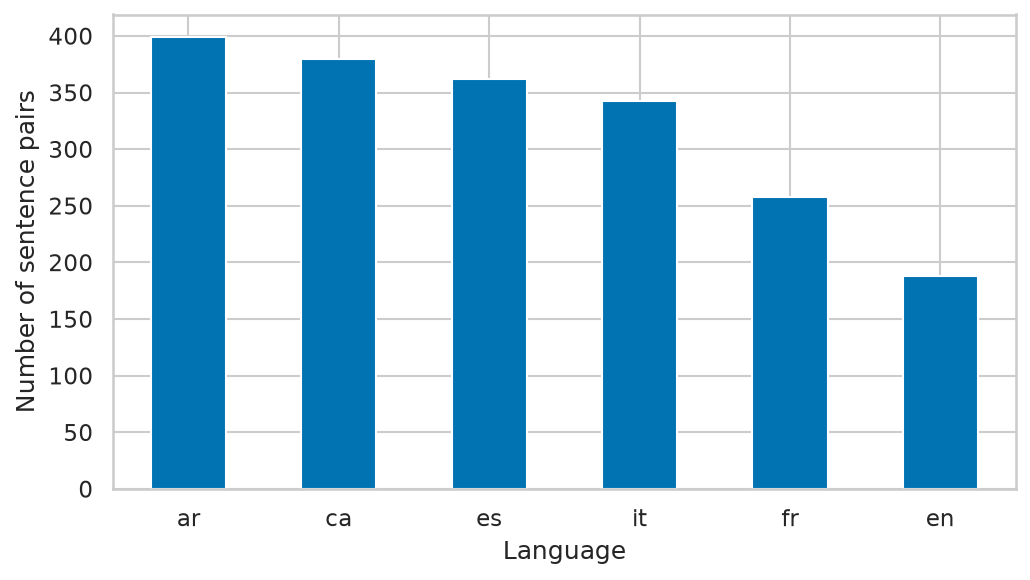

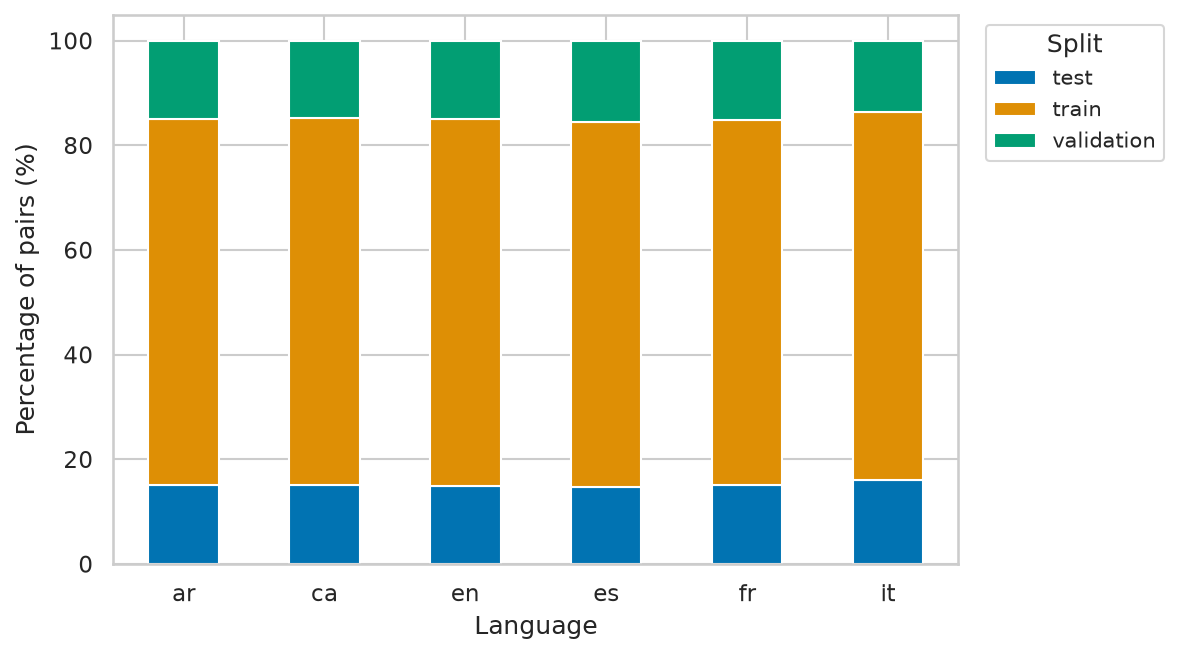

In [6]:
# 3. Dataset composition

# Counts by single dimension
by_language = pairs["language"].value_counts().rename("n_pairs")
by_collection = pairs["collection"].value_counts().rename("n_pairs")
by_split = pairs["split"].value_counts().rename("n_pairs")
by_document = pairs.groupby("language")["document_id"].nunique().rename("n_documents")

table_02 = pd.concat(
    [
        by_language.rename_axis("language").reset_index().assign(dimension="language"),
    ],
    ignore_index=True,
)

# Build a tidy composition table: one row per dimension value, with counts and percentages
composition_rows = []
for dim_name, series in [("language", by_language), ("collection", by_collection), ("split", by_split)]:
    total = series.sum()
    for value, count in series.items():
        composition_rows.append({
            "dimension": dim_name,
            "value": value,
            "n_pairs": count,
            "pct": round(100 * count / total, 2),
        })

table_02 = pd.DataFrame(composition_rows)
table_02.to_csv(TABLES_DIR / "table_02_dataset_composition.csv", index=False)

# Documents per language and collection
docs_by_language = pairs.groupby("language")["document_id"].nunique().rename("n_documents")
docs_by_collection = pairs.groupby("collection")["document_id"].nunique().rename("n_documents")

# Language x split, collection x split cross-tabs
language_split_counts = pd.crosstab(pairs["language"], pairs["split"])
language_split_counts["total"] = language_split_counts.sum(axis=1)
language_split_counts = language_split_counts.join(docs_by_language)
language_split_counts.to_csv(TABLES_DIR / "table_03_language_split_counts.csv")

collection_split_counts = pd.crosstab(pairs["collection"], pairs["split"])
collection_split_counts["total"] = collection_split_counts.sum(axis=1)

print("=== table_02_dataset_composition.csv ===")
print(table_02.to_string(index=False))
print()
print("=== table_03_language_split_counts.csv ===")
print(language_split_counts.to_string())
print()
print("=== collection x split (for reference) ===")
print(collection_split_counts.to_string())

# Figure 1: pairs by language
fig, ax = plt.subplots(figsize=(7, 4))
by_language.sort_values(ascending=False).plot(kind="bar", ax=ax, color=sns.color_palette("colorblind")[0])
ax.set_xlabel("Language")
ax.set_ylabel("Number of sentence pairs")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_01_pairs_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_01_pairs_by_language.png", dpi=300)
plt.show()

# Figure 2: split distribution by language (stacked, with clear denominator)
split_by_lang_pct = pd.crosstab(pairs["language"], pairs["split"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
split_by_lang_pct.plot(kind="bar", stacked=True, ax=ax, color=sns.color_palette("colorblind", n_colors=split_by_lang_pct.shape[1]))
ax.set_xlabel("Language")
ax.set_ylabel("Percentage of pairs (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Split", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_02_split_distribution_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_02_split_distribution_by_language.png", dpi=300)
plt.show()

## Questions to answer

- Which languages and collections are largest and smallest?
- Is Italian dominated by the main Italian collection?
- Is the train/validation/test allocation reasonably consistent across languages?
- Which language-level comparisons may have lower statistical power?

**Intern response:**
* **Largest/smallest**: Arabic is the biggest language (399 pairs, 20.7%), English the smallest (188, 9.7%). At the collection level, it_carlo is tiny (23 pairs, 1.2%); by far the smallest slice of the whole dataset

* **Is Italian dominated by the main collection**? Yes, iDEM Italian provides 320 of Italian's 343 pairs (93%), with Carlo Italian contributing just 23 (7%)

* **Is train/val/test allocation consistent across languages**? Yes, reasonably so. Every language sits close to a 70/15/15 split (e.g. Arabic: 70.0/15.0/15.0, Italian: 70.3/15.9/13.8, English: 70.2/14.9/14.9). No language is wildly off that pattern

* **Which comparisons may have lower statistical power**? Anything involving it_carlo specifically (only 23 pairs total, and just 3–4 pairs in validation/test). Any language or collection-level statistic broken down that finely will be unreliable. English, at 188 pairs, is also comparatively small next to Arabic/Catalan/Spanish

# 4. Sentence-length analysis

## Derived variables

Create at least:

- `length_difference = n_target_tokens - n_source_tokens`
- `tokens_removed = n_source_tokens - n_target_tokens`
- `length_reduction_rate = (n_source_tokens - n_target_tokens) / n_source_tokens`
- categorical direction: `shorter`, `same`, or `longer`

Keep negative reduction values; they represent target expansion.

## Descriptive statistics

Report count, mean, standard deviation, median, Q1, Q3, minimum and maximum for source length, target length, difference, ratio and reduction rate:

- overall;
- by language;
- by collection;
- by split.

### Required outputs

- `table_04_length_summary_overall.csv`
- `table_05_length_summary_by_language.csv`
- `table_06_length_direction_by_language.csv`
- `figure_03_source_target_lengths_by_language.pdf` and `.png`
- `figure_04_length_reduction_distribution.pdf` and `.png`

Use a paired visualisation or grouped box/violin plots for source versus target lengths. Make extreme outliers visible without allowing them to hide the central distribution.

=== table_04: overall length summary ===
  group              variable  count      mean       std  median        q1        q3   min        max
overall       n_source_tokens   1930 25.506736 17.764142    22.0 12.000000 34.000000   1.0 230.000000
overall       n_target_tokens   1930 26.408290 20.770940    21.0 11.000000 35.000000   1.0 214.000000
overall     length_difference   1930  0.901554 12.995339     0.0 -4.000000  4.000000 -67.0  96.000000
overall        tokens_removed   1930 -0.901554 12.995339     0.0 -4.000000  4.000000 -96.0  67.000000
overall length_reduction_rate   1930 -0.165606  2.300733     0.0 -0.213906  0.178571 -96.0   0.859155

=== table_05: length summary by language (source/target tokens only) ===
group        variable  count      mean       std  median   q1   q3  min   max
   ar n_source_tokens    399 21.654135 14.407587    18.0 12.0 28.0  3.0 114.0
   ar n_target_tokens    399 16.421053 10.724890    14.0  9.0 21.0  3.0  76.0
   ca n_source_tokens    380 30.413158 

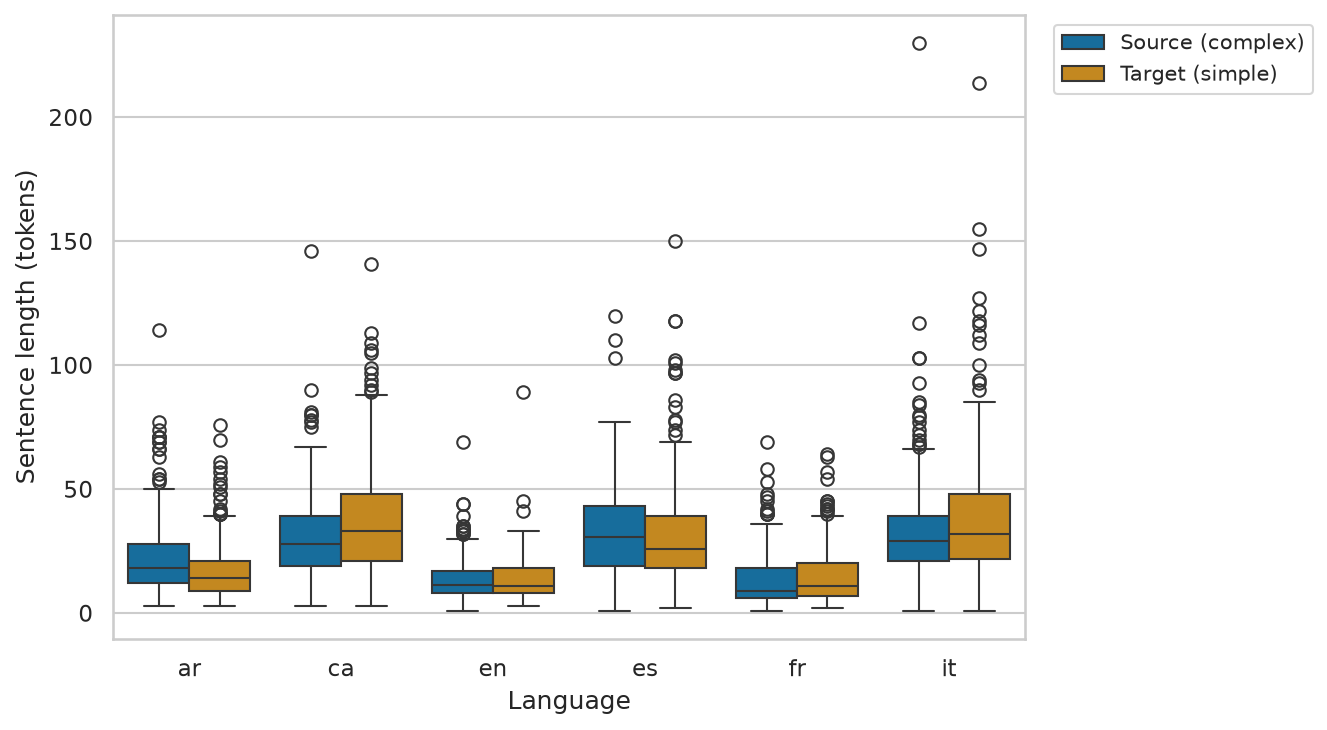

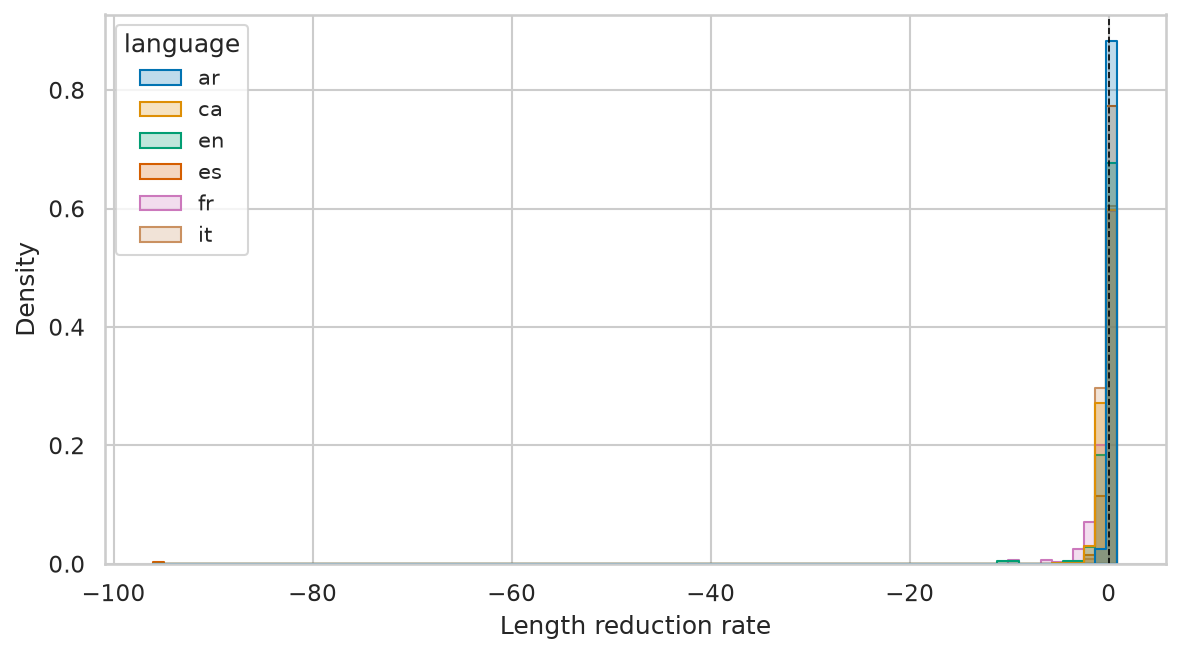

In [7]:
# 4. Sentence-length analysis

# Derived variables
pairs["length_difference"] = pairs["n_target_tokens"] - pairs["n_source_tokens"]
pairs["tokens_removed"] = pairs["n_source_tokens"] - pairs["n_target_tokens"]
pairs["length_reduction_rate"] = (pairs["n_source_tokens"] - pairs["n_target_tokens"]) / pairs["n_source_tokens"]

def direction(row):
    if row["n_target_tokens"] < row["n_source_tokens"]:
        return "shorter"
    elif row["n_target_tokens"] > row["n_source_tokens"]:
        return "longer"
    return "same"

pairs["length_direction"] = pairs.apply(direction, axis=1)

# Descriptive statistics helper
def describe_group(df, value_cols, group_col=None):
    rows = []
    groups = [("overall", df)] if group_col is None else list(df.groupby(group_col))
    for group_value, group_df in groups:
        for col in value_cols:
            s = group_df[col]
            rows.append({
                "group": group_value,
                "variable": col,
                "count": s.count(),
                "mean": s.mean(),
                "std": s.std(),
                "median": s.median(),
                "q1": s.quantile(0.25),
                "q3": s.quantile(0.75),
                "min": s.min(),
                "max": s.max(),
            })
    return pd.DataFrame(rows)

length_vars = [
    "n_source_tokens", "n_target_tokens", "length_difference",
    "tokens_removed", "length_reduction_rate",
]

# table_04: overall
table_04 = describe_group(pairs, length_vars)
table_04.to_csv(TABLES_DIR / "table_04_length_summary_overall.csv", index=False)

# table_05: by language
table_05 = describe_group(pairs, length_vars, group_col="language")
table_05.to_csv(TABLES_DIR / "table_05_length_summary_by_language.csv", index=False)

# Also compute by collection and by split, for completeness
table_05_by_collection = describe_group(pairs, length_vars, group_col="collection")
table_05_by_split = describe_group(pairs, length_vars, group_col="split")

# table_06: length direction by language
table_06 = pd.crosstab(pairs["language"], pairs["length_direction"], normalize="index") * 100
table_06["n_pairs"] = pairs.groupby("language").size()
table_06.to_csv(TABLES_DIR / "table_06_length_direction_by_language.csv")

print("=== table_04: overall length summary ===")
print(table_04.to_string(index=False))
print()
print("=== table_05: length summary by language (source/target tokens only) ===")
print(table_05[table_05["variable"].isin(["n_source_tokens", "n_target_tokens"])].to_string(index=False))
print()
print("=== table_06: length direction by language (%) ===")
print(table_06.to_string())

# Figure 3: paired source vs target lengths by language
plot_df = pairs.melt(
    id_vars=["language"],
    value_vars=["n_source_tokens", "n_target_tokens"],
    var_name="side", value_name="n_tokens"
)
plot_df["side"] = plot_df["side"].map({"n_source_tokens": "Source (complex)", "n_target_tokens": "Target (simple)"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="language", y="n_tokens", hue="side", ax=ax, palette="colorblind", showfliers=True)
ax.set_xlabel("Language")
ax.set_ylabel("Sentence length (tokens)")
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_03_source_target_lengths_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_03_source_target_lengths_by_language.png", dpi=300)
plt.show()

# Figure 4: length reduction rate distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=pairs, x="length_reduction_rate", hue="language", element="step", stat="density", common_norm=False, ax=ax, palette="colorblind")
ax.set_xlabel("Length reduction rate")
ax.set_ylabel("Density")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_04_length_reduction_distribution.pdf")
fig.savefig(FIGURES_DIR / "figure_04_length_reduction_distribution.png", dpi=300)
plt.show()

## Statistical analysis of length change

After inspecting the distributions:

1. Test whether target token length differs from source token length overall.
2. Repeat the paired comparison within each language.
3. Report an effect size and 95% confidence interval, not only a p-value.
4. Correct the language-level p-values for multiple comparisons using Holm correction.
5. Report the percentage of pairs that became shorter, stayed equal or became longer.

A paired Wilcoxon signed-rank test is suitable when the difference distribution is non-normal. Explain the test choice. Do not rely on a large-sample Shapiro test as the sole decision criterion.

Save the results as `table_07_length_tests.csv`.

In [8]:
# Statistical analysis of length change

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def wilcoxon_effect_size(source, target):
    """Paired Wilcoxon signed-rank test with a rank-biserial effect size
    and a bootstrap 95% CI for the median difference."""
    diff = target - source
    diff_nonzero = diff[diff != 0]  # wilcoxon drops zero-differences internally, but we need n for effect size
    n = len(diff_nonzero)

    stat, p = wilcoxon(source, target, zero_method="wilcox")

    # Rank-biserial effect size via normal approximation
    mean_w = n * (n + 1) / 4
    std_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z = (stat - mean_w) / std_w
    r = z / np.sqrt(n)

    # Bootstrap 95% CI for the median difference
    rng = np.random.default_rng(RANDOM_SEED)
    boot_medians = [
        np.median(rng.choice(diff, size=len(diff), replace=True))
        for _ in range(2000)
    ]
    ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])

    return {
        "n": len(source),
        "n_nonzero_diff": n,
        "median_diff": np.median(diff),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "wilcoxon_stat": stat,
        "p_value": p,
        "effect_size_r": r,
    }

length_test_rows = []

# Overall test
overall_result = wilcoxon_effect_size(pairs["n_source_tokens"].values, pairs["n_target_tokens"].values)
overall_result["group"] = "overall"
length_test_rows.append(overall_result)

# Per-language tests
for lang, group in pairs.groupby("language"):
    result = wilcoxon_effect_size(group["n_source_tokens"].values, group["n_target_tokens"].values)
    result["group"] = lang
    length_test_rows.append(result)

table_07 = pd.DataFrame(length_test_rows)
table_07 = table_07[["group", "n", "n_nonzero_diff", "median_diff", "ci_low", "ci_high", "wilcoxon_stat", "p_value", "effect_size_r"]]

# Holm correction applied only across the per-language tests (the overall test is a separate question)
language_mask = table_07["group"] != "overall"
_, p_corrected, _, _ = multipletests(table_07.loc[language_mask, "p_value"], method="holm")
table_07["p_value_holm"] = table_07["p_value"]
table_07.loc[language_mask, "p_value_holm"] = p_corrected

table_07.to_csv(TABLES_DIR / "table_07_length_tests.csv", index=False)

print(table_07.to_string(index=False))
print()
print("Length direction, all pairs:")
print(pairs["length_direction"].value_counts(normalize=True).mul(100).round(2))

  group    n  n_nonzero_diff  median_diff  ci_low  ci_high  wilcoxon_stat      p_value  effect_size_r  p_value_holm
overall 1930            1658          0.0     0.0      0.0       683321.0 8.239023e-01      -0.005460  8.239023e-01
     ar  399             332         -3.0    -3.0     -2.0         3721.5 1.152361e-42      -0.749981  6.914167e-42
     ca  380             345          2.0     1.0      3.0        15397.5 6.351369e-15      -0.419495  3.175684e-14
     en  188             149          0.0     0.0      0.0         5331.5 6.268939e-01      -0.039745  6.268939e-01
     es  362             325         -2.0    -2.5     -1.0        18628.0 3.490922e-06      -0.257169  1.047277e-05
     fr  258             186          0.0     0.0      1.0         6172.0 5.892392e-04      -0.251664  1.178478e-03
     it  343             321          2.0     1.0      3.0        14088.5 1.577120e-12      -0.394166  6.308481e-12

Length direction, all pairs:
length_direction
shorter    46.01
longer  

## Interpretation

Explain the magnitude of change, not merely whether it is statistically significant. Identify languages with expansion as well as reduction. Do not equate shortening with simplification quality.

**Intern response:**
* **Overall** (**pooled across all languages**): no significant length change (p=0.82, effect size ≈ 0). But that's misleading in isolation, it's not that nothing's happening, it's that opposite effects in different languages cancel each other out.

* **Arabic shortens strongly and significantly**: Median -3 tokens, by far the largest effect size (r = -0.75). This matches the 74.7% "shorter" figure from earlier

* **Spanish also shortens significantly**, though more modestly (median -2, r = -0.26)

* **Catalan and Italian expand significantly**: Median +2 tokens each (r = -0.42 and -0.39), consistent with the 58-59% "longer" figures from table_06

* **French is significant despite a median difference of 0**: Worth flagging as a subtlety: the test detects an asymmetric shift in the distribution (via ranks) even though the median sits exactly at zero, so French's simplifications aren't uniformly longer or shorter; they're more varied/mixed in direction

* **English shows no significant change** (p=0.63): Simplification there doesn't reliably make sentences longer or shorter, just different

# 5. Alignment analysis

## Task

Analyse:

- `n_alignment_links`;
- `source_alignment_coverage`;
- `target_alignment_coverage`;
- links per source token;
- links per target token;
- number and percentage of pairs below sensible coverage thresholds such as 0.50, 0.70 and 0.90.

Report the results overall and by language and collection.

### Required outputs

- `table_08_alignment_summary.csv`
- `table_09_low_coverage_pairs.csv`
- `figure_05_alignment_coverage_by_language.pdf` and `.png`
- `figure_06_source_vs_target_coverage.pdf` and `.png`

For the second figure, use a scatter plot with a diagonal reference line. Consider transparency because points overlap.

=== table_08: alignment summary (coverage variables only) ===
   group                  variable  count      mean       std  median      q1       q3   min   max  dimension
 overall source_alignment_coverage   1930 77.897503 17.753896  79.170 66.6700  92.5475 10.53 100.0    overall
 overall target_alignment_coverage   1930 78.662523 20.173464  81.820 63.6400 100.0000  3.09 100.0    overall
      ar source_alignment_coverage    399 79.218647 19.507496  83.330 67.2050  96.0750 20.00 100.0   language
      ar target_alignment_coverage    399 96.712431  8.213312 100.000 97.5900 100.0000 38.10 100.0   language
      ca source_alignment_coverage    380 78.325184 13.227178  78.260 68.4200  87.1000 40.62 100.0   language
      ca target_alignment_coverage    380 69.327868 17.714895  69.635 57.0450  81.8200 15.22 100.0   language
      en source_alignment_coverage    188 80.498404 22.529892  88.195 66.3475 100.0000 10.53 100.0   language
      en target_alignment_coverage    188 81.519043 21.225

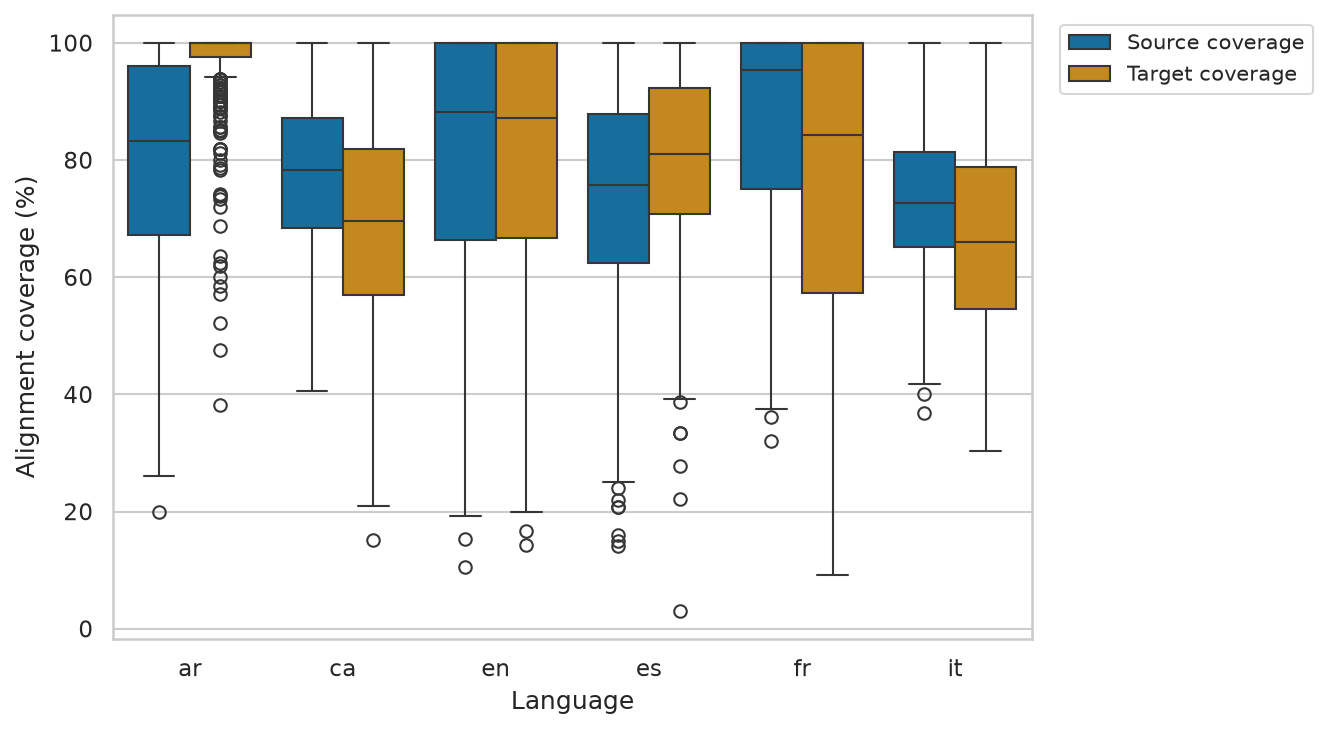

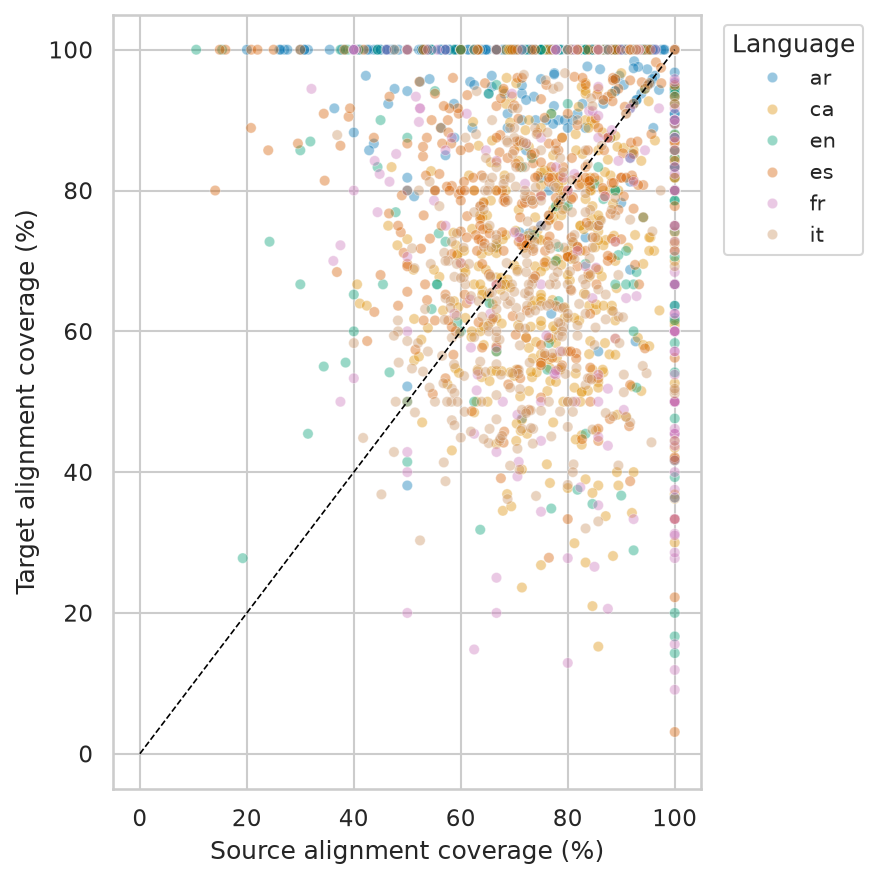

In [9]:
# 5. Alignment analysis

# Derived variables
pairs["links_per_source_token"] = pairs["n_alignment_links"] / pairs["n_source_tokens"]
pairs["links_per_target_token"] = pairs["n_alignment_links"] / pairs["n_target_tokens"]

alignment_vars = [
    "n_alignment_links", "source_alignment_coverage", "target_alignment_coverage",
    "links_per_source_token", "links_per_target_token",
]

# table_08: alignment summary, overall + by language + by collection
table_08_overall = describe_group(pairs, alignment_vars).assign(dimension="overall")
table_08_language = describe_group(pairs, alignment_vars, group_col="language").assign(dimension="language")
table_08_collection = describe_group(pairs, alignment_vars, group_col="collection").assign(dimension="collection")

table_08 = pd.concat([table_08_overall, table_08_language, table_08_collection], ignore_index=True)
table_08.to_csv(TABLES_DIR / "table_08_alignment_summary.csv", index=False)

print("=== table_08: alignment summary (coverage variables only) ===")
print(table_08[table_08["variable"].isin(["source_alignment_coverage", "target_alignment_coverage"])].to_string(index=False))

# table_09: pairs below coverage thresholds
# NOTE: coverage columns are stored as percentages (0-100), so thresholds are 50/70/90
thresholds = [50, 70, 90]
low_coverage_rows = []

for threshold in thresholds:
    for side, col in [("source", "source_alignment_coverage"), ("target", "target_alignment_coverage")]:
        below = pairs[pairs[col] < threshold]
        low_coverage_rows.append({
            "threshold": threshold,
            "side": side,
            "n_pairs_below": len(below),
            "pct_pairs_below": round(100 * len(below) / len(pairs), 2),
        })

table_09_summary = pd.DataFrame(low_coverage_rows)

# Also save the actual low-coverage pairs (using the strictest threshold, 90) for inspection
table_09_pairs = pairs[
    (pairs["source_alignment_coverage"] < 90) | (pairs["target_alignment_coverage"] < 90)
][["pair_id", "language", "collection", "source_alignment_coverage", "target_alignment_coverage"]]

table_09_summary.to_csv(TABLES_DIR / "table_09_low_coverage_pairs.csv", index=False)

print()
print("=== table_09: pairs below coverage thresholds ===")
print(table_09_summary.to_string(index=False))
print()
print(f"Total pairs below 90% coverage (either side): {len(table_09_pairs)} ({100*len(table_09_pairs)/len(pairs):.2f}%)")

# Figure 5: alignment coverage by language
plot_df = pairs.melt(
    id_vars=["language"],
    value_vars=["source_alignment_coverage", "target_alignment_coverage"],
    var_name="side", value_name="coverage"
)
plot_df["side"] = plot_df["side"].map({
    "source_alignment_coverage": "Source coverage",
    "target_alignment_coverage": "Target coverage",
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="language", y="coverage", hue="side", ax=ax, palette="colorblind")
ax.set_xlabel("Language")
ax.set_ylabel("Alignment coverage (%)")
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_05_alignment_coverage_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_05_alignment_coverage_by_language.png", dpi=300)
plt.show()

# Figure 6: source vs target coverage scatter, with diagonal reference line
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(
    data=pairs, x="source_alignment_coverage", y="target_alignment_coverage",
    hue="language", alpha=0.4, s=25, ax=ax, palette="colorblind",
)
ax.plot([0, 100], [0, 100], color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Source alignment coverage (%)")
ax.set_ylabel("Target alignment coverage (%)")
ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_06_source_vs_target_coverage.pdf")
fig.savefig(FIGURES_DIR / "figure_06_source_vs_target_coverage.png", dpi=300)
plt.show()

## Alignment questions

- Which language has the lowest typical source or target coverage?
- Are low-coverage observations rare outliers or a systematic subgroup?
- Is low coverage related to source length?
- Could low alignment coverage cause genuine edits to be labelled incorrectly?
- Propose one coverage threshold for a later sensitivity analysis, but do not remove any pair yet.

**Intern response:**
* **Lowest coverage**: Italian has the lowest alignment coverage on both source (73.2%) and target (67.4%) sides. Noticeably weaker than every other language

* **Rare outliers or systematic**?  it's systematic, and lines up with what I found in Section 4: Italian (along with Catalan) tends to expand during simplification rather than shorten, so more of the target sentence ends up as new, unaligned content

* **Related to source length**? Checked directly whether coverage relates to source length using Spearman correlation: source coverage vs source length gives rho=-0.522, target coverage vs source length gives rho=-0.271. Both moderate negative correlations, so longer source sentences do tend to have worse alignment coverage

* **Could low coverage mislabel genuine edits**? Yes: A token that's technically alignable but the alignment algorithm missed will look identical in the data to a genuine DELETE/INSERT, which could inflate apparent edit rates for low-coverage languages like Italian

* **Propose a threshold for later sensitivity analysis**: Given the numbers, 70% seems like a reasonable candidate. Strict enough to exclude clearly poor alignments, without excluding the majority of the dataset like 90% would.

# 6. Human-edit operation analysis

## Preparation

Merge the pair-level split information into `source_tokens.csv`.

Validate that, within every pair:

- the number of token rows equals `n_source_tokens`;
- operation counts sum to the source-token count;
- binary masks contain only 0 and 1;
- `content_edit` is not marked for punctuation excluded by `is_content`.

## Descriptive analysis

Create:

- operation counts and percentages overall;
- operation counts and percentages by language;
- operation counts and percentages by collection;
- pair-level counts of each operation;
- pair-level lexical, full and content edit rates;
- prevalence of any reordering.

### Required outputs

- `table_10_operation_counts_overall.csv`
- `table_11_operation_profile_by_language.csv`
- `table_12_pair_edit_rate_summary.csv`
- `figure_07_operation_profile_by_language.pdf` and `.png`
- `figure_08_content_edit_rate_by_language.pdf` and `.png`
- `figure_09_operation_support.pdf` and `.png`

A normalised stacked bar chart or heatmap is suitable for operation profiles. Also show absolute support somewhere, because percentages alone can hide small samples.

All Section 6 preparation checks passed.
source_tokens with split merged: 49228 rows

=== table_10: operation counts overall ===
 operation  count       pct
      KEEP  23768 48.281466
    DELETE  13553 27.531080
SUBSTITUTE   7865 15.976680
     MERGE   2094  4.253677
   COMPLEX   1217  2.472170
     SPLIT    731  1.484927

=== table_11: operation profile by language (%) ===
group  COMPLEX    DELETE      KEEP    MERGE    SPLIT  SUBSTITUTE  n_tokens dimension
   ar 1.678241 25.208333 60.474537 6.041667 0.312500    6.284722      8640  language
   ca 3.478411 25.153587 45.669291 5.191659 2.197802   18.309250     11557  language
   en 1.070336 27.331804 54.510703 2.599388 1.490826   12.996942      2616  language
   es 2.059343 30.654787 46.978230 3.303354 0.966630   16.037657     11897  language
   fr 2.010490 23.164336 53.933566 3.525641 1.923077   15.442890      3432  language
   it 2.958687 29.866498 39.680678 3.517951 2.074689   21.901497     11086  language

=== table_12: pair-level e

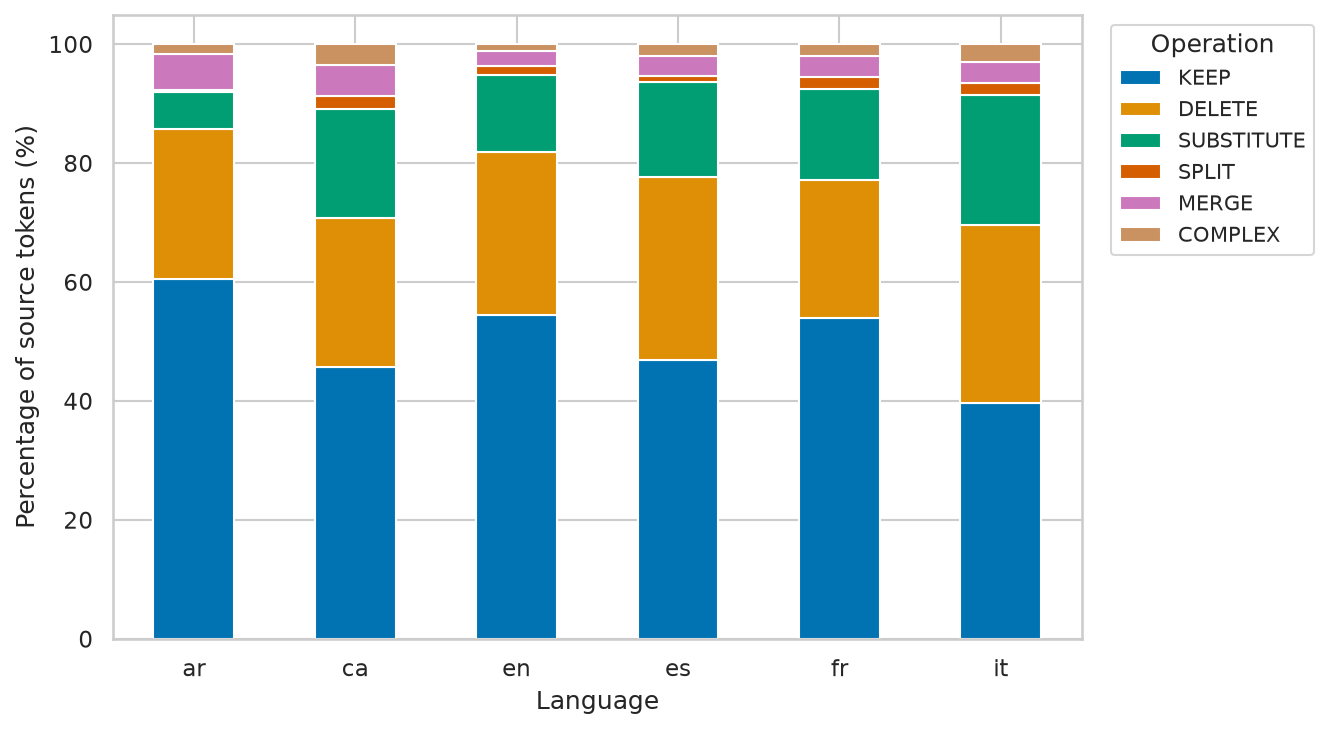

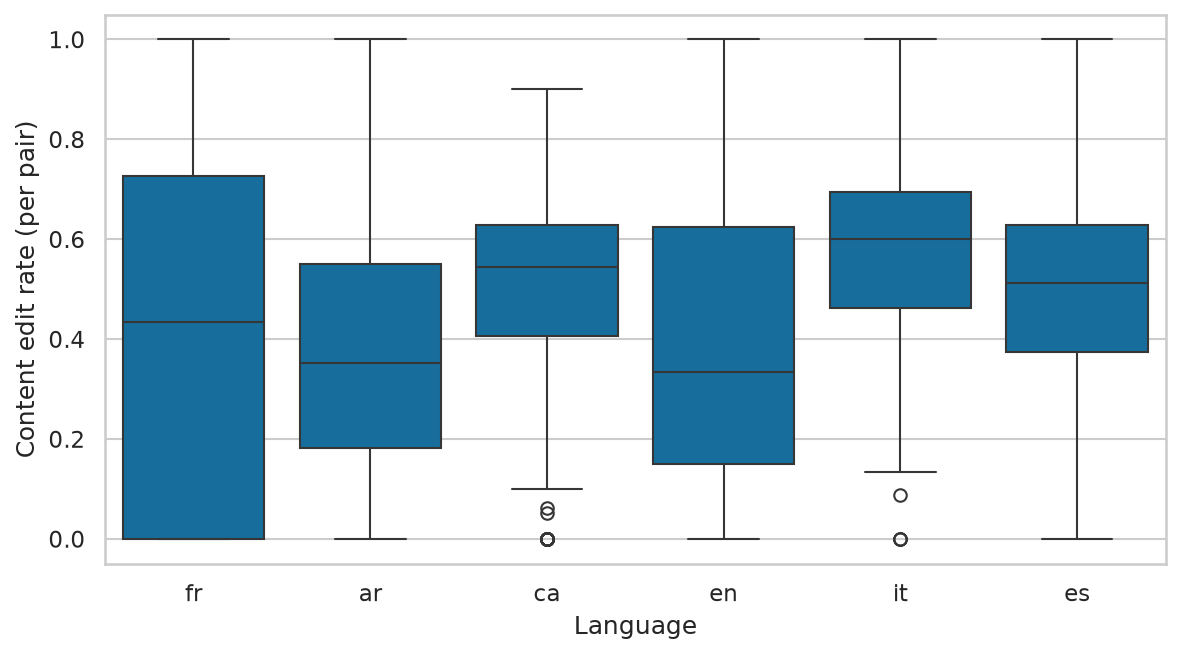

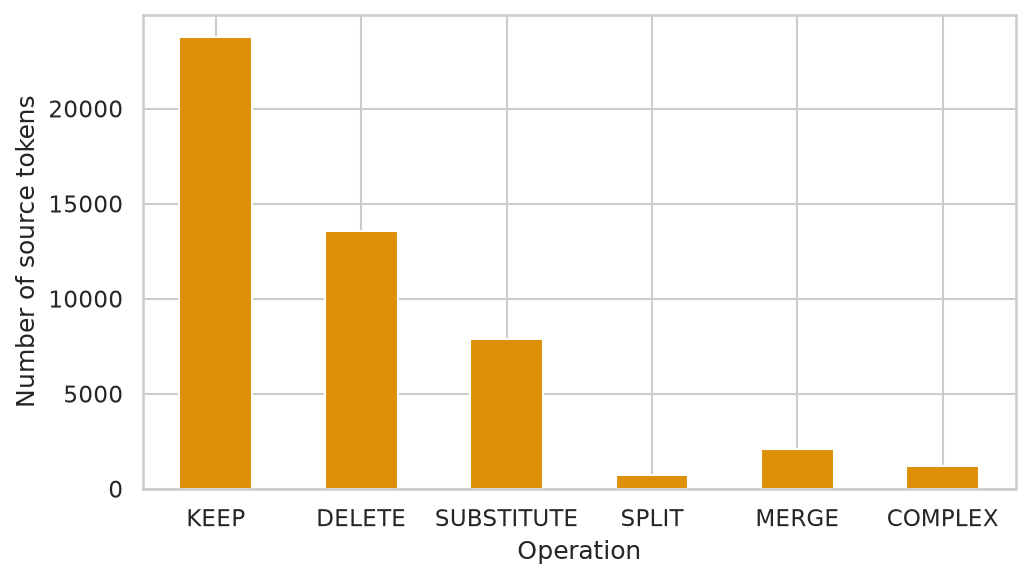

In [12]:
# 6. Human-edit operation analysis

WORD_LEVEL_DIR = PROJECT_ROOT / "Word-level"
LANGUAGES = ["ar", "ca", "en", "es", "fr", "it"]


# Preparation: merge split info, validate source_tokens.csv

source_tokens = source_tokens.merge(pairs[["pair_id", "split"]], on="pair_id", how="left")

# Check 1: token row count per pair matches n_source_tokens
row_counts = source_tokens.groupby("pair_id").size()
expected_counts = pairs.set_index("pair_id")["n_source_tokens"]
mismatch = (row_counts != expected_counts.loc[row_counts.index]).sum()
assert mismatch == 0, f"{mismatch} pairs have mismatched token row counts"

# Check 2: operation binary masks sum to exactly 1 per token
op_cols = ["is_keep", "is_delete", "is_substitute", "is_split", "is_merge", "is_complex"]
assert (source_tokens[op_cols].sum(axis=1) == 1).all(), "Operation masks must sum to 1 per token"

# Check 3: all binary mask columns only contain 0/1
for col in op_cols + ["is_punctuation", "is_content", "content_edit"]:
    bad_values = set(source_tokens[col].unique()) - {0, 1}
    assert not bad_values, f"{col} contains non-binary values: {bad_values}"

# Check 4: content_edit is never marked on punctuation tokens
punct_content_edit = source_tokens[(source_tokens["is_punctuation"] == 1) & (source_tokens["content_edit"] == 1)]
assert len(punct_content_edit) == 0, "content_edit marked on a punctuation token"

print("All Section 6 preparation checks passed.")
print(f"source_tokens with split merged: {len(source_tokens)} rows")


# table_10: operation counts and percentages, overall

op_counts = source_tokens["operation"].value_counts()
op_pcts = source_tokens["operation"].value_counts(normalize=True) * 100
table_10 = pd.DataFrame({"operation": op_counts.index, "count": op_counts.values, "pct": op_pcts.values})
table_10.to_csv(TABLES_DIR / "table_10_operation_counts_overall.csv", index=False)

print()
print("=== table_10: operation counts overall ===")
print(table_10.to_string(index=False))


# table_11: operation profile by language and by collection

def profile_by(group_col):
    counts = source_tokens.groupby([group_col, "operation"]).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    out = pct.copy()
    out["n_tokens"] = counts.sum(axis=1)
    out["dimension"] = group_col
    return out.reset_index().rename(columns={group_col: "group"})

table_11_language = profile_by("language")
table_11_collection = profile_by("collection")
table_11 = pd.concat([table_11_language, table_11_collection], ignore_index=True)
table_11.to_csv(TABLES_DIR / "table_11_operation_profile_by_language.csv", index=False)

print()
print("=== table_11: operation profile by language (%) ===")
print(table_11_language.to_string(index=False))


# table_12: pair-level operation counts and edit rates

pair_op_counts = source_tokens.groupby(["pair_id", "operation"]).size().unstack(fill_value=0)
for op in ["KEEP", "DELETE", "SUBSTITUTE", "SPLIT", "MERGE", "COMPLEX"]:
    if op not in pair_op_counts.columns:
        pair_op_counts[op] = 0
pair_op_counts = pair_op_counts.rename(columns={op: f"n_{op.lower()}" for op in pair_op_counts.columns})

pair_summary = source_tokens.groupby("pair_id").agg(
    n_tokens=("token_index", "count"),
    n_content_tokens=("is_content", "sum"),
    n_content_edits=("content_edit", "sum"),
)
pair_summary["full_edit_rate"] = 1 - (pair_op_counts["n_keep"] / pair_summary["n_tokens"])
pair_summary["content_edit_rate"] = pair_summary["n_content_edits"] / pair_summary["n_content_tokens"]

# NOTE / ASSUMPTION: "lexical edit rate" isn't formally defined in the task text.
# Defined here as the share of tokens undergoing a substitution-type edit
# (SUBSTITUTE / MERGE / COMPLEX), as distinct from purely structural DELETE/SPLIT.
# Worth confirming this definition with Nouran before treating it as final.

pair_summary["lexical_edit_rate"] = (
    pair_op_counts[["n_substitute", "n_merge", "n_complex"]].sum(axis=1) / pair_summary["n_tokens"]
)

# Reordering: computed from raw alignment topology, not human strategy labels
# (deliberately separate from the annotated "Transposition" strategy column, since
# Section 6 is alignment-derived evidence, not the human-strategy interpretation
# covered later in Part II)

sentence_level = pd.read_csv(PROJECT_ROOT / "Sentence-level" / "all_languages_sentence_strategy_alignment.csv", encoding="utf-8-sig")
template = pd.read_csv(PROJECT_ROOT / "Task1" / "strategy_annotations_template.csv", encoding="utf-8-sig")
crosswalk = sentence_level[["sentence_alignment_id", "language_code", "source_text", "target_text"]].merge(
    template[["pair_id", "language", "source_text", "target_text"]],
    left_on=["language_code", "source_text", "target_text"], right_on=["language", "source_text", "target_text"], how="inner",
)
id_map = crosswalk.set_index("sentence_alignment_id")["pair_id"].to_dict()

reorder_flags = {}
for lang in LANGUAGES:
    wl = pd.read_csv(WORD_LEVEL_DIR / f"{lang}_word_alignment.csv", encoding="utf-8-sig", low_memory=False)
    wl["pair_id"] = wl["sentence_alignment_id"].map(id_map)
    # Restrict to clean one-to-one aligned links, so SPLIT/MERGE fan-out isn't
    # mistaken for genuine word-order reordering
    aligned = wl[(wl["alignment_status"] == "aligned") & (wl["alignment_cardinality"] == "one_to_one")].sort_values(["pair_id", "source_token_index"])
    for pid, group in aligned.groupby("pair_id"):
        tgt_seq = group["target_token_index"].tolist()
        reorder_flags[pid] = False if len(tgt_seq) < 2 else not all(tgt_seq[i] <= tgt_seq[i+1] for i in range(len(tgt_seq)-1))

pair_summary["has_reordering"] = pair_summary.index.map(reorder_flags).fillna(False)

table_12 = pair_summary.reset_index().merge(pair_op_counts.reset_index(), on="pair_id", how="left")
table_12 = table_12.merge(pairs[["pair_id", "language", "collection", "split"]], on="pair_id", how="left")
table_12.to_csv(TABLES_DIR / "table_12_pair_edit_rate_summary.csv", index=False)

print()
print("=== table_12: pair-level edit rate summary (sample) ===")
print(table_12.head(3).to_string(index=False))
print()
print(f"Pairs with reordering detected: {table_12['has_reordering'].sum()} ({100*table_12['has_reordering'].mean():.2f}%)")
print()
print("Content edit rate by language (mean / median):")
print(table_12.groupby("language")["content_edit_rate"].agg(["mean", "median"]))


# Figures

op_order = ["KEEP", "DELETE", "SUBSTITUTE", "SPLIT", "MERGE", "COMPLEX"]

# figure_07: operation profile by language (normalised stacked bar)
fig, ax = plt.subplots(figsize=(9, 5))
table_11_language.set_index("group")[op_order].plot(kind="bar", stacked=True, ax=ax, color=sns.color_palette("colorblind", len(op_order)))
ax.set_xlabel("Language")
ax.set_ylabel("Percentage of source tokens (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Operation", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_07_operation_profile_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_07_operation_profile_by_language.png", dpi=300)
plt.show()

# figure_08: content edit rate by language (pair-level boxplot)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=table_12, x="language", y="content_edit_rate", ax=ax, color=sns.color_palette("colorblind")[0])
ax.set_xlabel("Language")
ax.set_ylabel("Content edit rate (per pair)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_08_content_edit_rate_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_08_content_edit_rate_by_language.png", dpi=300)
plt.show()

# figure_09: operation support (absolute counts, since percentages hide small samples)
fig, ax = plt.subplots(figsize=(7, 4))
table_10.set_index("operation").loc[op_order, "count"].plot(kind="bar", ax=ax, color=sns.color_palette("colorblind")[1])
ax.set_xlabel("Operation")
ax.set_ylabel("Number of source tokens")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_09_operation_support.pdf")
fig.savefig(FIGURES_DIR / "figure_09_operation_support.png", dpi=300)
plt.show()

## Operation-profile statistics

At the **sentence-pair level**, investigate whether edit behaviour differs by language.

Required analyses:

1. Compare pair-level content edit rates across languages using a suitable omnibus test.
2. If significant, conduct corrected post-hoc comparisons.
3. Test whether the categorical operation profile is associated with language.
4. Report effect sizes:
   - epsilon-squared or another justified effect size for the omnibus rank test;
   - Cramér's V for the operation × language contingency table.
5. Clearly distinguish descriptive token counts from pair-level inference.

Save as:

- `table_13_edit_rate_tests.csv`
- `table_14_operation_language_association.csv`

In [17]:
# Operation-profile statistics

from scipy.stats import kruskal, mannwhitneyu, chi2_contingency
from statsmodels.stats.multitest import multipletests
from itertools import combinations


# 1. Omnibus test: content edit rate across languages

languages_order = sorted(table_12["language"].unique())
groups = [table_12[table_12["language"] == lang]["content_edit_rate"].values for lang in languages_order]

H, p_omnibus = kruskal(*groups)
n_pairs_total = len(table_12)
k_groups = len(groups)
# Epsilon-squared effect size for Kruskal-Wallis (Tomczak & Tomczak, 2014)
epsilon_sq = (H - k_groups + 1) / (n_pairs_total - k_groups)

print(f"Kruskal-Wallis (content edit rate ~ language): H={H:.3f}, p={p_omnibus:.3e}, epsilon^2={epsilon_sq:.4f}")


# 2. Post-hoc pairwise comparisons (only meaningful since omnibus is significant),
#    Mann-Whitney U with Holm correction across all language pairs

pairwise_rows = []
for lang_a, lang_b in combinations(languages_order, 2):
    a = table_12[table_12["language"] == lang_a]["content_edit_rate"].values
    b = table_12[table_12["language"] == lang_b]["content_edit_rate"].values
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    pairwise_rows.append({"lang_a": lang_a, "lang_b": lang_b, "statistic": stat, "p_value": p})

pairwise_df = pd.DataFrame(pairwise_rows)
_, p_holm, _, _ = multipletests(pairwise_df["p_value"], method="holm")
pairwise_df["p_value_holm"] = p_holm
pairwise_df["significant_holm"] = pairwise_df["p_value_holm"] < 0.05
pairwise_df["test"] = "mannwhitney_" + pairwise_df["lang_a"] + "_vs_" + pairwise_df["lang_b"]

table_13 = pd.concat([
    pd.DataFrame([{
        "test": "kruskal_wallis_omnibus", "statistic": H, "p_value": p_omnibus,
        "p_value_holm": p_omnibus, "significant_holm": p_omnibus < 0.05,
        "lang_a": None, "lang_b": None,
    }]),
    pairwise_df,
], ignore_index=True)
table_13 = table_13[["test", "lang_a", "lang_b", "statistic", "p_value", "p_value_holm", "significant_holm"]]
table_13.to_csv(TABLES_DIR / "table_13_edit_rate_tests.csv", index=False)

print()
print("=== table_13: pairwise post-hoc comparisons (Holm-corrected) ===")
print(pairwise_df[["lang_a", "lang_b", "p_value", "p_value_holm", "significant_holm"]].to_string(index=False))


# 3. Chi-square: is the categorical operation profile associated with language?

contingency = pd.crosstab(source_tokens["language"], source_tokens["operation"])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)
n_tokens = contingency.values.sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n_tokens * min_dim))

table_14 = pd.DataFrame([{
    "test": "chi_square_operation_x_language",
    "chi2": chi2,
    "dof": dof,
    "p_value": p_chi2,
    "cramers_v": cramers_v,
    "n_tokens": int(n_tokens),
}])
table_14.to_csv(TABLES_DIR / "table_14_operation_language_association.csv", index=False)

print()
print("=== table_14: operation x language association ===")
print(table_14.to_string(index=False))

Kruskal-Wallis (content edit rate ~ language): H=169.352, p=1.003e-34, epsilon^2=0.0854

=== table_13: pairwise post-hoc comparisons (Holm-corrected) ===
lang_a lang_b      p_value  p_value_holm  significant_holm
    ar     ca 2.551728e-18  3.572419e-17              True
    ar     en 8.997049e-01  1.000000e+00             False
    ar     es 1.165070e-12  1.398084e-11              True
    ar     fr 2.139927e-01  6.419780e-01             False
    ar     it 7.362527e-32  1.104379e-30              True
    ca     en 4.299536e-09  4.729490e-08              True
    ca     es 7.919388e-02  3.167755e-01             False
    ca     fr 2.581061e-03  1.548636e-02              True
    ca     it 2.858784e-06  2.001149e-05              True
    en     es 8.305611e-07  6.644489e-06              True
    en     fr 5.234483e-01  1.000000e+00             False
    en     it 2.919127e-15  3.794865e-14              True
    es     fr 2.005357e-02  1.002678e-01             False
    es     it 7.0446

## Interpretation

- Which operations dominate overall?
- Which operations have low support and may produce unstable attribution estimates?
- Which languages show unusually high DELETE, SUBSTITUTE, MERGE, SPLIT or COMPLEX rates?
- Are differences likely to reflect actual simplification practice, alignment behaviour, collection composition, or a combination?

**Intern response:**
* KEEP is the dominant operation overall (48.3%), followed by DELETE (27.5%) and SUBSTITUTE (16.0%). These three account for over 90% of all edits

* SPLIT (1.5%) and COMPLEX (2.5%) have the lowest support, which is a risk flag for later attribution work; some per-language breakdowns of these (e.g. English's SPLIT rate) rest on only a few dozen tokens and won't be reliable

* Arabic has a distinct profile: unusually high MERGE (6.0%) and unusually low SUBSTITUTE (6.3%) compared to every other language

* Italian and Spanish show the highest DELETE rates (29.9% and 30.7%), and Italian also has the highest SUBSTITUTE rate (21.9%). This is consistent with Italian's heavier restructuring seen throughout the earlier sections

* Post-hoc comparisons show Arabic, English and French cluster together (not significantly different from each other), while Italian differs significantly from every other language. Catalan and Spanish are similar to each other but differ from the Arabic/English/French group

* Both effect sizes are small despite very low p-values (epsilon²=0.085, Cramér's V=0.087) — with ~1,930 pairs and ~49,000 tokens, even modest real differences become "significant." Statistically detectable is not the same as practically large

* Most likely explanation for Italian's distinctiveness: a combination of genuinely heavier simplification and its lower alignment coverage (Cell 28) inflating the apparent edit count. Cannot claim one cause over the other without further evidence

# 7. Relationships among variables

## Task

At the sentence-pair level, calculate and visualise relationships among:

- source length;
- target length;
- length reduction rate;
- source content edit rate;
- source and target alignment coverage;
- number of alignment links;
- counts of DELETE, SUBSTITUTE, MERGE, SPLIT and COMPLEX operations.

Use Spearman correlations unless a different choice is justified.

### Required outputs

- `table_15_spearman_correlations.csv`
- `figure_10_reduction_vs_edit_rate.pdf` and `.png`
- `figure_11_length_vs_number_of_edits.pdf` and `.png`
- `figure_12_pair_level_correlation_matrix.pdf` and `.png`

For scatter plots, show language using facets or clearly distinguishable groups. Avoid fitting a single regression line that hides language-level structure.

=== table_15: Spearman correlation matrix (key relationships) ===
                           length_reduction_rate  content_edit_rate  \
n_source_tokens                            0.148              0.276   
n_target_tokens                           -0.344              0.131   
length_reduction_rate                      1.000              0.223   
content_edit_rate                          0.223              1.000   
source_alignment_coverage                 -0.521             -0.730   
target_alignment_coverage                  0.659             -0.361   
n_alignment_links                         -0.087              0.058   
n_delete                                   0.388              0.611   
n_substitute                              -0.139              0.546   
n_merge                                    0.253              0.368   
n_split                                   -0.408              0.136   
n_complex                                 -0.112              0.233   
n_edits_tot

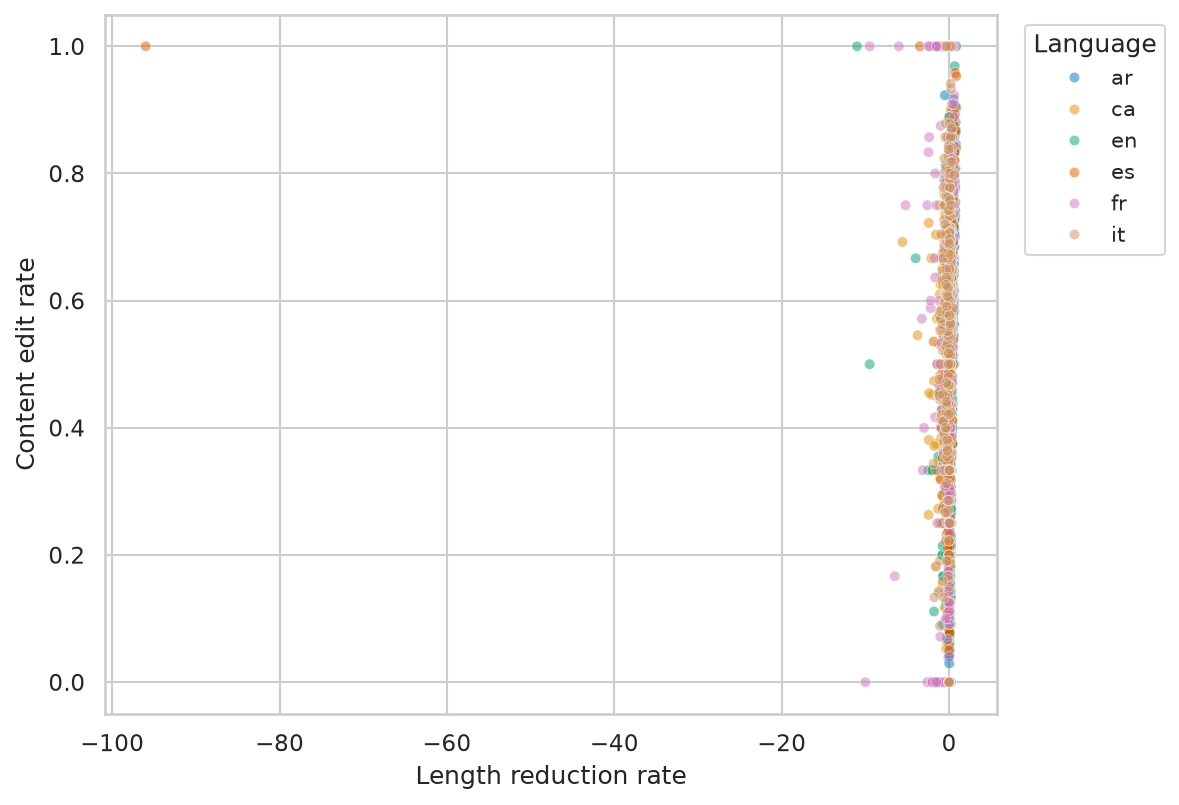

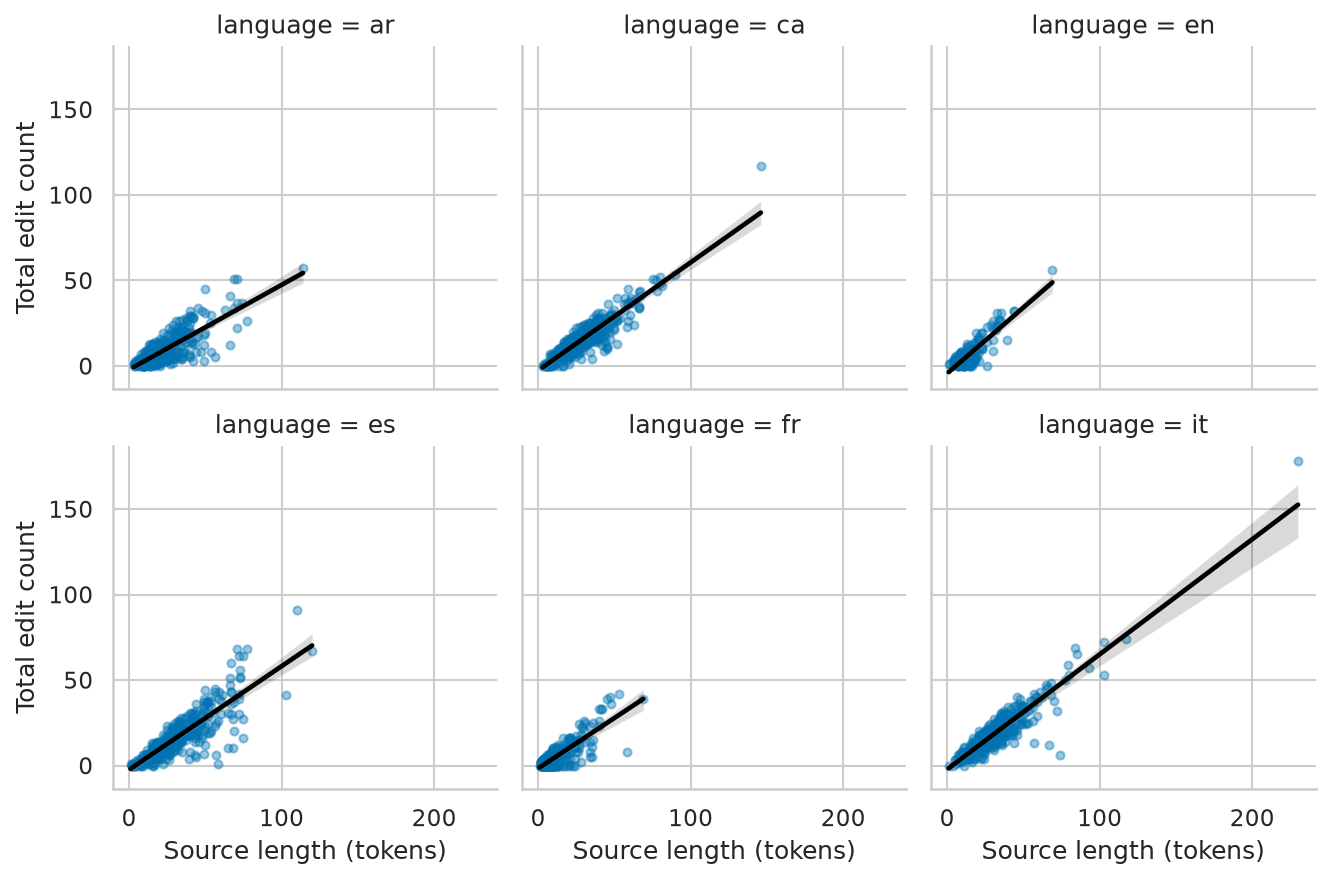

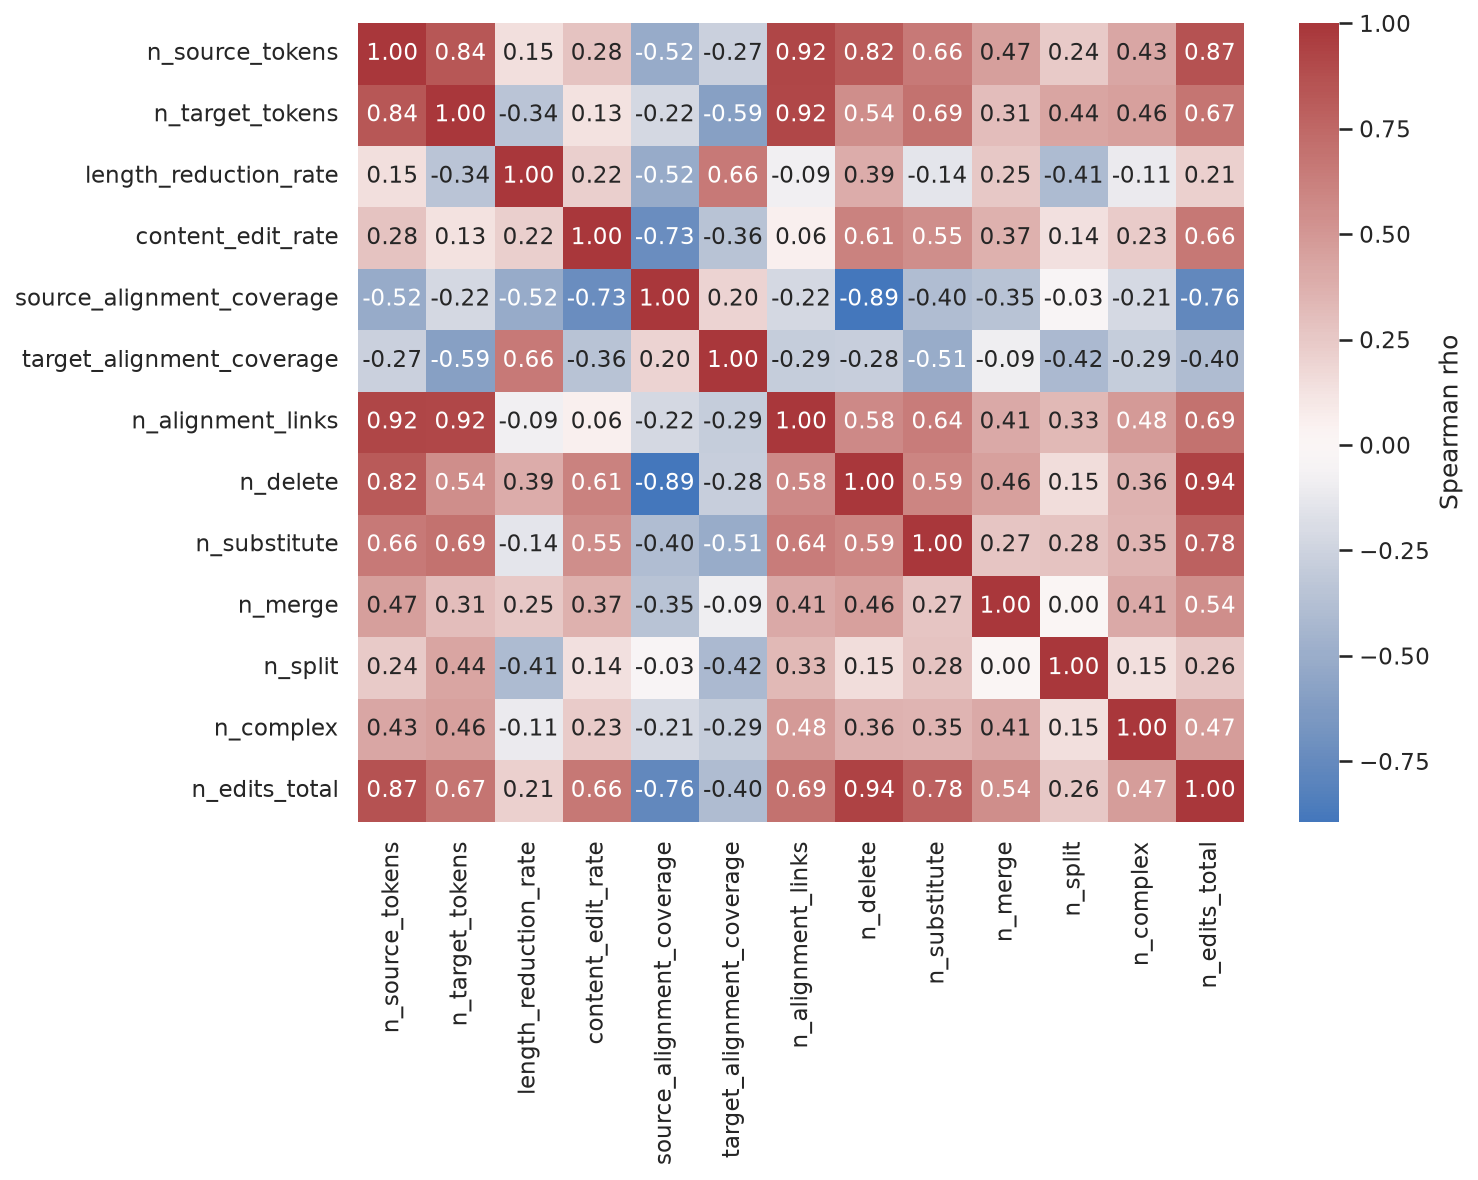

In [13]:
# 7. Relationships among variables


# Build the pair-level analysis table

analysis_df = pairs[[
    "pair_id", "language", "n_source_tokens", "n_target_tokens",
    "source_alignment_coverage", "target_alignment_coverage", "n_alignment_links",
]].merge(
    table_12[["pair_id", "content_edit_rate", "n_delete", "n_substitute", "n_merge", "n_split", "n_complex"]],
    on="pair_id", how="inner"
)
analysis_df["length_reduction_rate"] = (
    (analysis_df["n_source_tokens"] - analysis_df["n_target_tokens"]) / analysis_df["n_source_tokens"]
)
analysis_df["n_edits_total"] = analysis_df[["n_delete", "n_substitute", "n_merge", "n_split", "n_complex"]].sum(axis=1)


# table_15: Spearman correlation matrix

corr_vars = [
    "n_source_tokens", "n_target_tokens", "length_reduction_rate", "content_edit_rate",
    "source_alignment_coverage", "target_alignment_coverage", "n_alignment_links",
    "n_delete", "n_substitute", "n_merge", "n_split", "n_complex", "n_edits_total",
]
corr_matrix = analysis_df[corr_vars].corr(method="spearman")
corr_matrix.to_csv(TABLES_DIR / "table_15_spearman_correlations.csv")

print("=== table_15: Spearman correlation matrix (key relationships) ===")
print(corr_matrix[["length_reduction_rate", "content_edit_rate", "source_alignment_coverage", "n_edits_total"]].round(3))


# figure_10: length reduction rate vs content edit rate, by language

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=analysis_df, x="length_reduction_rate", y="content_edit_rate", hue="language", alpha=0.5, s=25, ax=ax, palette="colorblind")
ax.set_xlabel("Length reduction rate")
ax.set_ylabel("Content edit rate")
ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_10_reduction_vs_edit_rate.pdf")
fig.savefig(FIGURES_DIR / "figure_10_reduction_vs_edit_rate.png", dpi=300)
plt.show()


# figure_11: source length vs total edit count, faceted by language
# (faceted rather than one combined regression line, so language-level
# structure isn't hidden by a single pooled trend)

g = sns.lmplot(
    data=analysis_df, x="n_source_tokens", y="n_edits_total", col="language", col_wrap=3,
    scatter_kws={"alpha": 0.4, "s": 15}, line_kws={"color": "black"}, height=3,
)
g.set_axis_labels("Source length (tokens)", "Total edit count")
g.savefig(FIGURES_DIR / "figure_11_length_vs_number_of_edits.pdf")
g.savefig(FIGURES_DIR / "figure_11_length_vs_number_of_edits.png", dpi=300)
plt.show()


# figure_12: full pair-level correlation matrix heatmap

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, cbar_kws={"label": "Spearman rho"})
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_12_pair_level_correlation_matrix.pdf")
fig.savefig(FIGURES_DIR / "figure_12_pair_level_correlation_matrix.png", dpi=300)
plt.show()

## Questions

- Does greater shortening correspond to a higher content edit rate?
- Do longer sentences contain more edits simply because they contain more tokens?
- Does low alignment coverage systematically raise or lower the measured edit rate?
- Which variables may confound later attribution evaluation?

**Intern response:**
* Length reduction rate and content edit rate are only weakly related (rho=0.223) — shortening a sentence and heavily editing it aren't the same thing

* Longer sentences do have more total edits (rho=0.865 with n_edits_total), but that's mostly a length artifact, not proportionally more editing. The content edit rate (a proportion) only correlates weakly with source length (rho=0.276). So "longer = more edited" is largely just "longer = more tokens to potentially edit"

* Alignment coverage strongly affects the measured edit rate (rho=-0.730 with content edit rate) — lower coverage looks like heavier editing

* Two clear confounds for later attribution work: source length (inflates raw edit counts without meaning more was actually done per token) and alignment coverage (mechanically tied to DELETE specifically). Both should be reported or controlled for alongside attribution results, not treated as background noise

# 8. Train, validation and test comparability

## Task

Compare splits on:

- language and collection composition;
- source and target lengths;
- length reduction rate;
- source content edit rate;
- source and target alignment coverage;
- operation profile.

Produce:

- `table_16_split_comparison.csv`
- `figure_13_split_feature_comparison.pdf` and `.png`

The goal is not to force identical distributions. The goal is to identify differences that must be considered when interpreting classifier and attribution results.

=== Language composition by split (%) ===
split      test  train  validation
language                          
ar        20.55  20.64       20.98
ca        19.52  19.75       19.58
en         9.59   9.76        9.79
es        18.15  18.71       19.58
fr        13.36  13.31       13.64
it        18.84  17.83       16.43

=== table_16: split comparability tests ===
                 variable         H      p_value  epsilon_squared
          n_source_tokens  1.725828 4.219308e-01        -0.000142
          n_target_tokens 10.011883 6.698033e-03         0.004158
    length_reduction_rate 15.677594 3.941429e-04         0.007098
        content_edit_rate  2.979155 2.254679e-01         0.000508
source_alignment_coverage  3.501974 1.736026e-01         0.000779
target_alignment_coverage  6.767080 3.392714e-02         0.002474
 operation_profile (chi2) 67.069457 1.626041e-10         0.026100


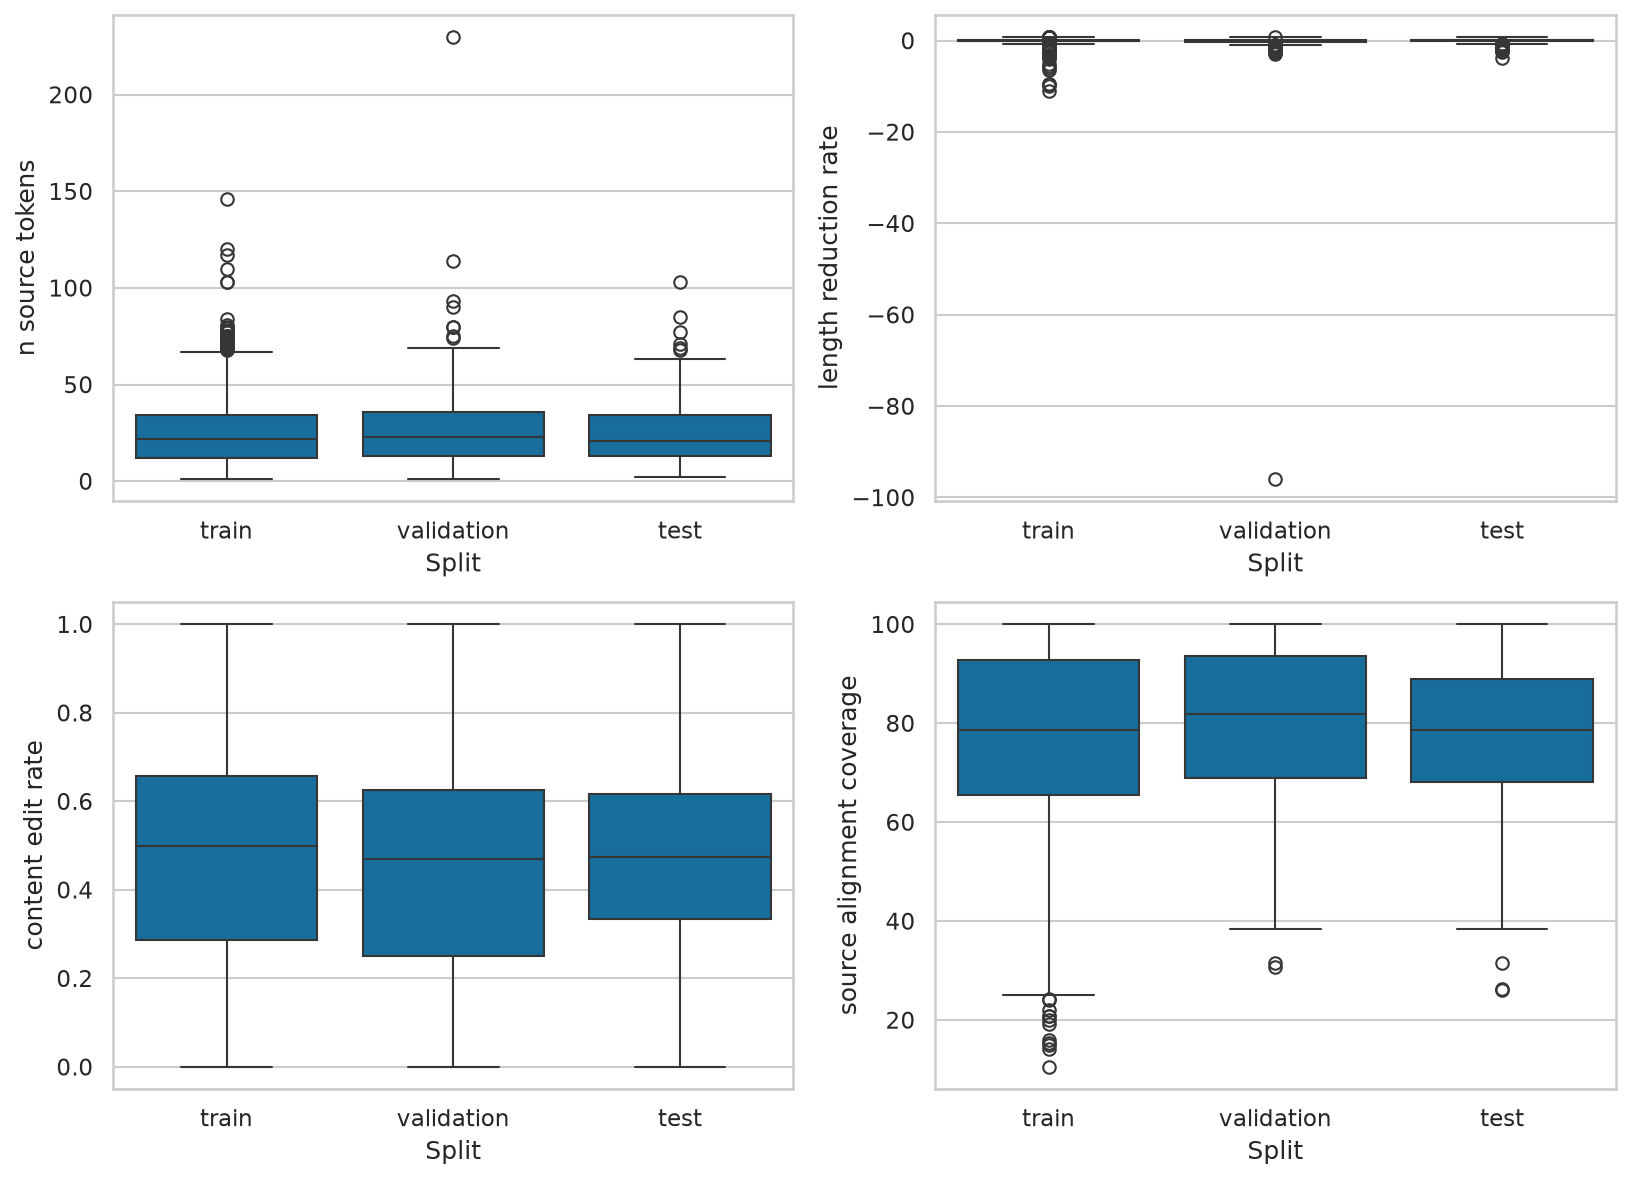

In [18]:
# 8. Train, validation and test comparability

from scipy.stats import kruskal, chi2_contingency


# Build the pair-level analysis table (reuse pattern from Section 7)

analysis_df = pairs[[
    "pair_id", "language", "collection", "split", "n_source_tokens", "n_target_tokens",
    "source_alignment_coverage", "target_alignment_coverage",
]].merge(
    table_12[["pair_id", "content_edit_rate"]], on="pair_id", how="inner"
)
analysis_df["length_reduction_rate"] = (
    (analysis_df["n_source_tokens"] - analysis_df["n_target_tokens"]) / analysis_df["n_source_tokens"]
)

splits_order = ["train", "validation", "test"]
numeric_vars = [
    "n_source_tokens", "n_target_tokens", "length_reduction_rate", "content_edit_rate",
    "source_alignment_coverage", "target_alignment_coverage",
]


# Composition: language and collection distribution by split

lang_split_pct = pd.crosstab(analysis_df["language"], analysis_df["split"], normalize="columns") * 100
collection_split_pct = pd.crosstab(analysis_df["collection"], analysis_df["split"], normalize="columns") * 100

print("=== Language composition by split (%) ===")
print(lang_split_pct.round(2))


# table_16: Kruskal-Wallis for each numeric variable across splits

rows = []
for var in numeric_vars:
    groups = [analysis_df[analysis_df["split"] == s][var].dropna().values for s in splits_order]
    H, p = kruskal(*groups)
    n = len(analysis_df)
    k = len(groups)
    eps_sq = (H - k + 1) / (n - k)
    rows.append({"variable": var, "H": H, "p_value": p, "epsilon_squared": eps_sq})

table_16 = pd.DataFrame(rows)

# Operation profile (categorical) association with split

if "split" not in source_tokens.columns:
    source_tokens = source_tokens.merge(pairs[["pair_id", "split"]], on="pair_id", how="left")

contingency = pd.crosstab(source_tokens["split"], source_tokens["operation"])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)
n_tokens_split = contingency.values.sum()
cramers_v_split = np.sqrt(chi2 / (n_tokens_split * (min(contingency.shape) - 1)))

table_16 = pd.concat([
    table_16,
    pd.DataFrame([{"variable": "operation_profile (chi2)", "H": chi2, "p_value": p_chi2, "epsilon_squared": cramers_v_split}]),
], ignore_index=True)

table_16.to_csv(TABLES_DIR / "table_16_split_comparison.csv", index=False)

print()
print("=== table_16: split comparability tests ===")
print(table_16.to_string(index=False))


# figure_13: key features compared across splits

plot_vars = ["n_source_tokens", "length_reduction_rate", "content_edit_rate", "source_alignment_coverage"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, var in zip(axes.flat, plot_vars):
    sns.boxplot(data=analysis_df, x="split", y=var, order=splits_order, ax=ax, color=sns.color_palette("colorblind")[0])
    ax.set_xlabel("Split")
    ax.set_ylabel(var.replace("_", " "))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_13_split_feature_comparison.pdf")
fig.savefig(FIGURES_DIR / "figure_13_split_feature_comparison.png", dpi=300)
plt.show()

## Split conclusion

State:

- whether the test set is broadly representative;
- which variables differ most;
- whether later XAI metrics should be macro-averaged by language as well as micro-averaged across all pairs.

**Intern response:**
* Test set is broadly representative; language composition, source length, content edit rate and source alignment coverage are all statistically indistinguishable from train

* A few variables (target token length, length reduction rate, target alignment coverage, operation profile) show statistically significant differences across splits, but every effect size is tiny (epsilon² between -0.0001 and 0.007, Cramér's V=0.026 for operation profile) — with this many pairs/tokens, even trivial differences can hit p<0.05, so these aren't practically meaningful

* The two variables most central to later modelling, source length and content edit rate, show no significant difference between splits at all

* Recommend macro-averaging later XAI metrics by language as well as micro-averaging overall, regardless of this split result. Sections 4-6 already showed languages differ substantially in length, alignment coverage and edit behaviour (especially Italian vs Arabic), so a single pooled metric risks hiding language-specific patterns the same way the pooled length-change test did back in Cell 24

# Part II. In-Depth Linguistic Edit and Strategy Analysis

These linguistic and strategy-readiness analyses form the second part of the same Stage 1 data-understanding task.

## Conceptual distinction

Alignment-derived operations and human simplification strategies are related, but they are **not interchangeable**.

Examples:

- an unaligned source token is evidence of a local `DELETE` operation, but it does not by itself prove that the whole sentence uses the macro-strategy **Omission**;
- an unaligned target token is an `INSERT`, but it may realise **Explanation**, grammatical repair, discourse marking or another strategy;
- `SUBSTITUTE` is a structural alignment operation, whereas the annotated strategy **Substitution** is a linguistic interpretation;
- `MERGE`, `SPLIT` and reordering may support **Compression**, **Syntactic Changes** or **Transposition**, but context is required;
- **Modulation** and **Transcription** cannot be identified reliably from alignment topology alone.

Every result must preserve this distinction.

# 9. Exact complex-versus-simple quartile and IQR analysis

## Mandatory table

For each language and each side separately:

- complex/original;
- simple/simplified;

report the following for sentence token count:

- number of sentences;
- mean;
- standard deviation;
- minimum;
- Q1;
- median;
- Q3;
- IQR (`Q3 - Q1`);
- maximum;
- 95% bootstrap confidence interval for the median.

Produce one row per `language × side`.

Save:

- `table_17_token_length_iqr_by_language_and_side.csv`
- `table_17_token_length_iqr_by_language_and_side.tex`

The labels in the output must be `Complex` and `Simple`, not only `source` and `target`.

In [19]:
# 9. Exact complex-versus-simple quartile and IQR analysis

def bootstrap_median_ci(values, n_boot=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boot_medians = [np.median(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return np.percentile(boot_medians, [2.5, 97.5])

rows = []
for lang, group in pairs.groupby("language"):
    for side, col in [("Complex", "n_source_tokens"), ("Simple", "n_target_tokens")]:
        s = group[col]
        ci_low, ci_high = bootstrap_median_ci(s.values)
        rows.append({
            "language": lang, "side": side, "n_sentences": s.count(),
            "mean": s.mean(), "std": s.std(), "min": s.min(),
            "q1": s.quantile(0.25), "median": s.median(), "q3": s.quantile(0.75),
            "iqr": s.quantile(0.75) - s.quantile(0.25), "max": s.max(),
            "median_ci_low": ci_low, "median_ci_high": ci_high,
        })

table_17 = pd.DataFrame(rows)
table_17.to_csv(TABLES_DIR / "table_17_token_length_iqr_by_language_and_side.csv", index=False)
with open(TABLES_DIR / "table_17_token_length_iqr_by_language_and_side.tex", "w") as f:
    f.write(table_17.round(2).to_latex(index=False))

print("=== table_17: token length IQR by language and side ===")
print(table_17.round(2).to_string(index=False))

=== table_17: token length IQR by language and side ===
language    side  n_sentences  mean   std  min   q1  median   q3  iqr  max  median_ci_low  median_ci_high
      ar Complex          399 21.65 14.41    3 12.0    18.0 28.0 16.0  114           17.0            19.0
      ar  Simple          399 16.42 10.72    3  9.0    14.0 21.0 12.0   76           13.0            15.0
      ca Complex          380 30.41 16.50    3 19.0    28.0 39.0 20.0  146           26.0            30.0
      ca  Simple          380 36.65 21.72    3 21.0    33.0 48.0 27.0  141           30.0            34.0
      en Complex          188 13.91  9.02    1  8.0    11.5 17.0  9.0   69           10.0            13.0
      en  Simple          188 13.78  9.21    3  8.0    11.0 18.0 10.0   89           10.0            12.0
      es Complex          362 32.86 18.39    1 19.0    30.5 43.0 24.0  120           29.0            33.0
      es  Simple          362 30.52 19.74    2 18.0    26.0 39.0 21.0  150           25.0       

## Additional paired quartile analysis

For each language, also report Q1, median, Q3 and IQR for:

- paired token difference: `simple_tokens - complex_tokens`;
- proportional reduction;
- character-count difference;
- content-word-count difference, after linguistic annotation is available.

Produce:

- `table_18_paired_change_iqr_by_language.csv`
- `figure_14_complex_simple_length_by_language.pdf` and `.png`
- `figure_15_paired_length_change_by_language.pdf` and `.png`

The first figure should make complex and simple distributions directly comparable within each language. The second should show the distribution of paired change, including expansion below zero where relevant.

=== table_18: paired change IQR by language ===
language               variable     q1  median    q3   iqr
      ar      paired_token_diff  -8.00   -3.00  0.00  8.00
      ar proportional_reduction   0.00    0.16  0.34  0.34
      ar              char_diff -38.50  -14.00 -2.00 36.50
      ca      paired_token_diff  -2.00    2.00 11.00 13.00
      ca proportional_reduction  -0.38   -0.10  0.07  0.45
      ca              char_diff -18.25    6.00 41.25 59.50
      en      paired_token_diff  -3.00    0.00  2.00  5.00
      en proportional_reduction  -0.25    0.00  0.20  0.45
      en              char_diff -12.25   -3.00 12.00 24.25
      es      paired_token_diff  -8.00   -2.00  2.00 10.00
      es proportional_reduction  -0.09    0.07  0.22  0.30
      es              char_diff -41.00  -12.00 11.75 52.75
      fr      paired_token_diff  -1.00    0.00  4.00  5.00
      fr proportional_reduction  -0.58    0.00  0.06  0.65
      fr              char_diff  -5.00    1.00 21.75 26.75
      it

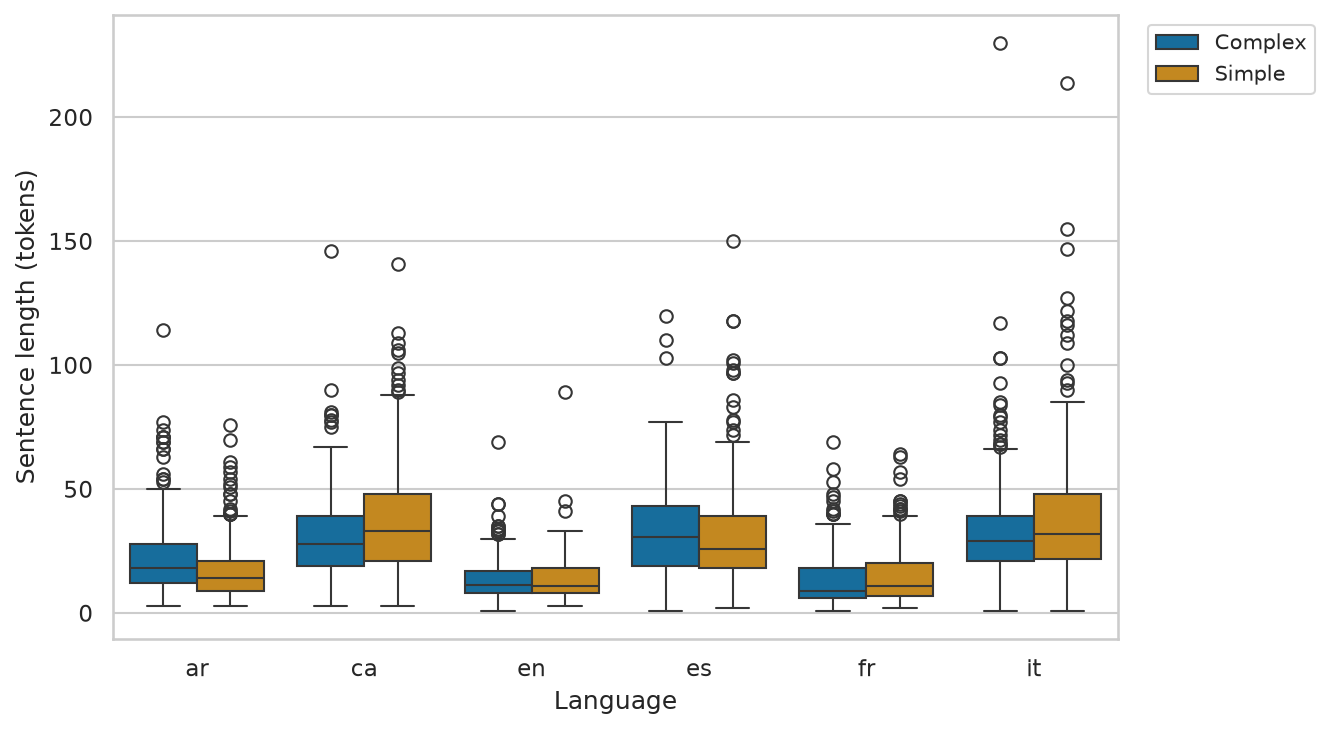

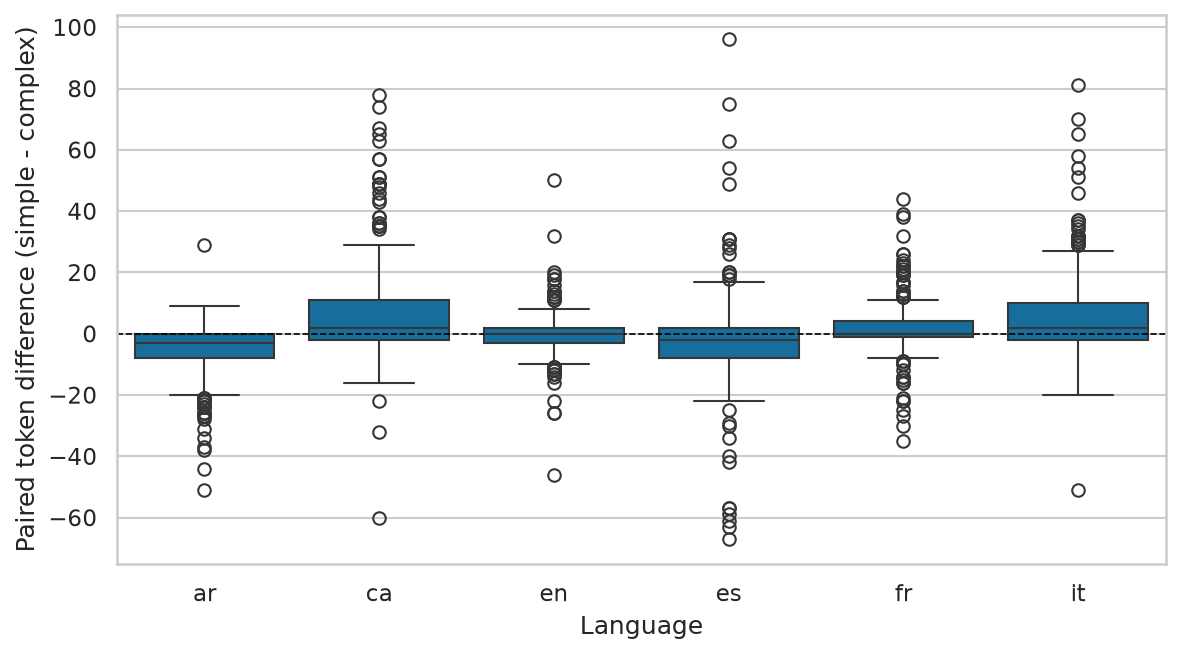

In [20]:
# Additional paired quartile analysis

pairs["paired_token_diff"] = pairs["n_target_tokens"] - pairs["n_source_tokens"]
pairs["proportional_reduction"] = (pairs["n_source_tokens"] - pairs["n_target_tokens"]) / pairs["n_source_tokens"]

# ASSUMPTION: character-count difference uses raw string length (including spaces
# and punctuation) of source_text/target_text, since no other character-counting
# convention is specified in the task.
pairs["char_diff"] = pairs["target_text"].str.len() - pairs["source_text"].str.len()

# NOTE: content-word-count difference is NOT computed here -- the task explicitly
# says this requires linguistic annotation, which is Section 12 (spaCy/UDPipe),
# not yet done at this point in the notebook.

paired_vars = ["paired_token_diff", "proportional_reduction", "char_diff"]

rows = []
for lang, group in pairs.groupby("language"):
    for var in paired_vars:
        s = group[var]
        rows.append({
            "language": lang, "variable": var,
            "q1": s.quantile(0.25), "median": s.median(), "q3": s.quantile(0.75),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
        })

table_18 = pd.DataFrame(rows)
table_18.to_csv(TABLES_DIR / "table_18_paired_change_iqr_by_language.csv", index=False)

print("=== table_18: paired change IQR by language ===")
print(table_18.round(2).to_string(index=False))


# figure_14: complex vs simple length distributions, directly comparable per language

plot_df = pairs.melt(id_vars=["language"], value_vars=["n_source_tokens", "n_target_tokens"], var_name="side", value_name="n_tokens")
plot_df["side"] = plot_df["side"].map({"n_source_tokens": "Complex", "n_target_tokens": "Simple"})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=plot_df, x="language", y="n_tokens", hue="side", ax=ax, palette="colorblind")
ax.set_xlabel("Language")
ax.set_ylabel("Sentence length (tokens)")
ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_14_complex_simple_length_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_14_complex_simple_length_by_language.png", dpi=300)
plt.show()


# figure_15: paired length change distribution, including expansion below zero

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=pairs, x="language", y="paired_token_diff", ax=ax, color=sns.color_palette("colorblind")[0])
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Language")
ax.set_ylabel("Paired token difference (simple - complex)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_15_paired_length_change_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_15_paired_length_change_by_language.png", dpi=300)
plt.show()

## Required interpretation

For every language, answer:

- What is the median complex sentence length?
- What is the median simple sentence length?
- What are the two IQRs?
- Is the simple distribution merely shifted downward, or is it also narrower or wider?
- Does the language contain a substantial group of expanded simplifications?
- Could different language-specific tokenisation practices affect direct comparison?

Do not compare raw token counts across languages without discussing tokenisation.

**Intern response:**

**Arabic**:

* Complex median 18 (IQR 16), Simple median 14 (IQR 12)

* Simple distribution is both shifted down and narrower than complex

* No substantial expansion group, even the 75th percentile of the paired token difference is 0, consistent with the 74.7% "shorter" finding from Section 4

**Catalan**:

* Complex median 28 (IQR 20), Simple median 33 (IQR 27)

* Simple distribution is shifted up and clearly wider and more variable, not just relocated

* Substantial expansion group: median paired difference is +2, and the IQR (-2 to +11) shows most pairs expand

**English**:

* Complex median 11.5 (IQR 9), Simple median 11 (IQR 10). Almost identical medians, slightly wider spread on the simple side

* No dominant direction. Paired difference is centred right at 0 (Q1=-3, Q3=+2), a genuine mix of shortening and expansion rather than one clear pattern

**Spanish**:

* Complex median 30.5 (IQR 24), Simple median 26 (IQR 21)

* Simple distribution shifted down and slightly narrower

* Mostly shorter but a real minority expand (Q3 of paired difference is +2). Not as one-sided as Arabic

**French**:

* Complex median 9 (IQR 12), Simple median 11 (IQR 13). Small upward shift, slightly wider

* Mixed/skewed toward expansion but centred at 0. Similar pattern to English, not a clean single direction

**Italian**:

* Complex median 29 (IQR 18), Simple median 32 (IQR 26)

* Simple distribution shifted up and substantially wider. The biggest spread increase of any language, meaning Italian simplifications vary a lot in how much they expand

* Clear expansion majority (median paired difference +2, IQR -2 to +10). The largest expansion spread in the dataset

**Tokenisation Caveat** (**applies across all of the above**):

* Token counts shouldn't be compared directly across languages, since tokenisation conventions differ (e.g. Arabic clitics/agglutination vs English word-boundary tokenisation). A "token" doesn't represent a consistent amount of content across languages

* Within-language complex-vs-simple comparisons (which is what all the above is doing) are safe, since tokenisation is at least consistent within each language pair

# 10. Build a two-sided token and edit table

The existing `source_tokens.csv` contains source-side operations. The pair file also contains `target_tokens` and `target_operations`.

## Task

Create a long-format token table with one row per token and the following fields:

- `pair_id`;
- language, collection, document and split;
- `side`: `complex` or `simple`;
- token index and surface form;
- operation;
- degree;
- aligned token indices;
- normalised token position from 0 to 1;
- punctuation/content/function status when available;
- linguistic annotations added later.

Validate:

- source-side operation counts against `source_tokens.csv`;
- target-side `INSERT` counts;
- token counts against the pair table;
- operation values against the allowed vocabulary.

Save:

- `derived_edit_tokens_long.csv`
- `table_19_two_sided_operation_counts.csv`

In [21]:
# 10. Build a two-sided token and edit table

ALLOWED_OPS = {"KEEP", "DELETE", "SUBSTITUTE", "SPLIT", "MERGE", "COMPLEX", "INSERT"}


# Complex (source) side: reuse the already-validated source_tokens.csv

complex_rows = source_tokens.merge(pairs[["pair_id", "split"]], on="pair_id", how="left") if "split" not in source_tokens.columns else source_tokens.copy()
complex_rows["side"] = "complex"
complex_rows = complex_rows.rename(columns={"token_index": "token_index_raw", "token": "token_text"})


# Simple (target) side: unpack the JSON lists from pairs_with_splits.csv

simple_rows_list = []
for _, row in pairs.iterrows():
    tgt_tokens = row["target_tokens"]
    tgt_ops = row["target_operations"]
    for idx in range(len(tgt_tokens)):
        simple_rows_list.append({
            "pair_id": row["pair_id"], "language": row["language"], "collection": row["collection"],
            "document_id": row["document_id"], "split": row["split"], "side": "simple",
            "token_index_raw": idx, "token_text": tgt_tokens[idx], "operation": tgt_ops[idx],
        })
simple_rows = pd.DataFrame(simple_rows_list)


# Combine into one long table

keep_cols = ["pair_id", "language", "collection", "document_id", "split", "side", "token_index_raw", "token_text", "operation"]
derived_edit_tokens_long = pd.concat([complex_rows[keep_cols], simple_rows[keep_cols]], ignore_index=True)

# Normalised token position (0 to 1) within each pair x side
derived_edit_tokens_long["n_tokens_side"] = derived_edit_tokens_long.groupby(["pair_id", "side"])["token_index_raw"].transform("count")
derived_edit_tokens_long["normalised_position"] = (
    derived_edit_tokens_long["token_index_raw"] / (derived_edit_tokens_long["n_tokens_side"] - 1).replace(0, 1)
)


# Validation

bad_ops = set(derived_edit_tokens_long["operation"].unique()) - ALLOWED_OPS
assert not bad_ops, f"Unexpected operation values found: {bad_ops}"

# Source-side operation counts must match source_tokens.csv exactly
src_check = derived_edit_tokens_long[derived_edit_tokens_long["side"] == "complex"]["operation"].value_counts().sort_index()
src_actual = source_tokens["operation"].value_counts().sort_index()
assert (src_check == src_actual).all(), "Source-side operation counts do not match source_tokens.csv"

# Target-side INSERT count sanity check (INSERT only exists on the target/simple side)
assert "DELETE" not in derived_edit_tokens_long[derived_edit_tokens_long["side"] == "simple"]["operation"].unique(), (
    "DELETE should never appear on the simple/target side"
)

# Token counts per pair must match the pair table
n_complex_check = derived_edit_tokens_long[derived_edit_tokens_long["side"] == "complex"].groupby("pair_id").size().sort_index()
n_simple_check = derived_edit_tokens_long[derived_edit_tokens_long["side"] == "simple"].groupby("pair_id").size().sort_index()
expected_source = pairs.set_index("pair_id")["n_source_tokens"].sort_index()
expected_target = pairs.set_index("pair_id")["n_target_tokens"].sort_index()
assert (n_complex_check == expected_source.loc[n_complex_check.index]).all(), "Complex-side token counts mismatch"
assert (n_simple_check == expected_target.loc[n_simple_check.index]).all(), "Simple-side token counts mismatch"

print("All Section 10 validations passed.")
print(f"Total rows: {len(derived_edit_tokens_long)} (complex: {len(complex_rows)}, simple: {len(simple_rows)})")


# table_19: two-sided operation counts

table_19 = derived_edit_tokens_long.groupby(["side", "operation"]).size().rename("count").reset_index()
table_19["pct_within_side"] = table_19.groupby("side")["count"].transform(lambda x: 100 * x / x.sum())
table_19.to_csv(TABLES_DIR / "table_19_two_sided_operation_counts.csv", index=False)

print()
print("=== table_19: two-sided operation counts ===")
print(table_19.round(2).to_string(index=False))


# Save the derived long-format token table

DERIVED_DIR = PROJECT_ROOT / "data" / "derived"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)
derived_edit_tokens_long.to_csv(DERIVED_DIR / "derived_edit_tokens_long.csv", index=False)
print()
print(f"Saved to {DERIVED_DIR / 'derived_edit_tokens_long.csv'}")

All Section 10 validations passed.
Total rows: 100196 (complex: 49228, simple: 50968)

=== table_19: two-sided operation counts ===
   side  operation  count  pct_within_side
complex    COMPLEX   1217             2.47
complex     DELETE  13553            27.53
complex       KEEP  23768            48.28
complex      MERGE   2094             4.25
complex      SPLIT    731             1.48
complex SUBSTITUTE   7865            15.98
 simple    COMPLEX   1192             2.34
 simple     INSERT  15215            29.85
 simple       KEEP  23768            46.63
 simple      MERGE    684             1.34
 simple      SPLIT   2244             4.40
 simple SUBSTITUTE   7865            15.43

Saved to /workspaces/Interpretating-Readability-Evaluation-with-Explainable-AI/data/derived/derived_edit_tokens_long.csv


# 11. Deletion and addition span analysis

A deletion is a contiguous sequence of source tokens labelled `DELETE`. An addition is a contiguous sequence of target tokens labelled `INSERT`.

## Task 11A: Identify edit spans

Within each pair and side:

1. sort tokens by index;
2. group consecutive `DELETE` or `INSERT` tokens into spans;
3. retain the span text, length, start and end indices;
4. calculate normalised span location:
   - beginning: midpoint < 0.33;
   - middle: 0.33–0.66;
   - end: > 0.66;
5. record whether the span is one token or multiple tokens.

Produce:

- `derived_deletion_addition_spans.csv`
- `table_20_span_length_and_location.csv`
- `figure_16_deletion_addition_span_lengths.pdf` and `.png`
- `figure_17_edit_location_by_language.pdf` and `.png`

Delete spans: 6906, Insert spans: 7101
Span sanity checks passed (every DELETE/INSERT token accounted for exactly once).

=== table_20 (overall rows) ===
operation   scope  n_spans  median_length  q1_length  q3_length  iqr_length  pct_single_token  pct_beginning  pct_middle  pct_end
   DELETE overall     6906            1.0        1.0        2.0         1.0             57.33          31.74       34.26    34.00
   INSERT overall     7101            1.0        1.0        2.0         1.0             52.32          32.49       33.22    34.29

Pairs containing both deletion and addition spans: 1184 (61.3%)


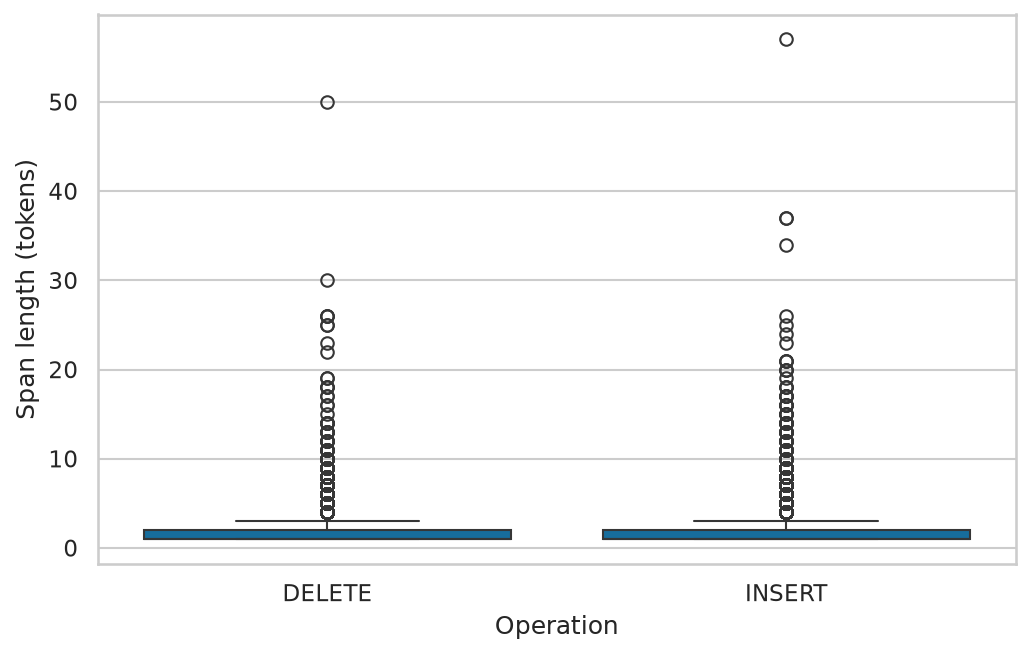

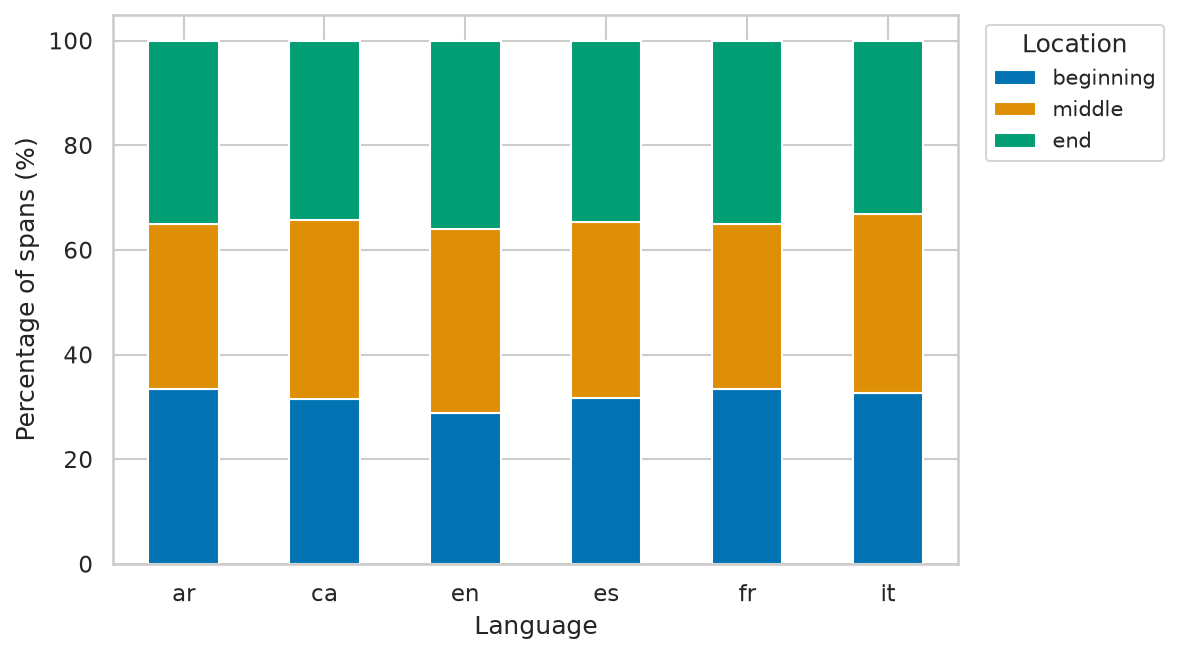

In [22]:
# 11. Deletion and addition span analysis

def find_spans(df, side, target_op):
    """Find contiguous runs of target_op within each pair, for one side."""
    subset = df[df["side"] == side].sort_values(["pair_id", "token_index_raw"])
    spans = []
    for pid, group in subset.groupby("pair_id"):
        group = group.reset_index(drop=True)
        n_tokens_side = group["n_tokens_side"].iloc[0]
        is_target = (group["operation"] == target_op).values
        idx = 0
        while idx < len(group):
            if is_target[idx]:
                start = idx
                while idx < len(group) and is_target[idx]:
                    idx += 1
                end = idx - 1
                span_tokens = group["token_text"].iloc[start:end + 1].tolist()
                start_pos = group["token_index_raw"].iloc[start]
                end_pos = group["token_index_raw"].iloc[end]
                midpoint_norm = ((start_pos + end_pos) / 2) / max(n_tokens_side - 1, 1)
                location = "beginning" if midpoint_norm < 0.33 else ("end" if midpoint_norm > 0.66 else "middle")
                spans.append({
                    "pair_id": pid, "side": side, "operation": target_op,
                    "span_text": " ".join(map(str, span_tokens)),
                    "span_length": end - start + 1,
                    "start_index": start_pos, "end_index": end_pos,
                    "normalised_midpoint": midpoint_norm, "location": location,
                    "is_multi_token": (end - start + 1) > 1,
                })
            else:
                idx += 1
    return pd.DataFrame(spans)


# Task 11A: identify spans

delete_spans = find_spans(derived_edit_tokens_long, "complex", "DELETE")
insert_spans = find_spans(derived_edit_tokens_long, "simple", "INSERT")

derived_spans = pd.concat([delete_spans, insert_spans], ignore_index=True)
derived_spans = derived_spans.merge(
    derived_edit_tokens_long[["pair_id", "language", "collection", "document_id", "split"]].drop_duplicates("pair_id"),
    on="pair_id", how="left"
)

# Sanity check: every DELETE/INSERT token must be accounted for exactly once across spans
n_delete_tokens = (derived_edit_tokens_long[derived_edit_tokens_long["side"] == "complex"]["operation"] == "DELETE").sum()
n_insert_tokens = (derived_edit_tokens_long[derived_edit_tokens_long["side"] == "simple"]["operation"] == "INSERT").sum()
assert delete_spans["span_length"].sum() == n_delete_tokens, "DELETE span lengths don't sum to total DELETE tokens"
assert insert_spans["span_length"].sum() == n_insert_tokens, "INSERT span lengths don't sum to total INSERT tokens"

derived_spans.to_csv(DERIVED_DIR / "derived_deletion_addition_spans.csv", index=False)
print(f"Delete spans: {len(delete_spans)}, Insert spans: {len(insert_spans)}")
print("Span sanity checks passed (every DELETE/INSERT token accounted for exactly once).")


# table_20: span length and location summary, overall and by language

rows = []
for op, group in derived_spans.groupby("operation"):
    rows.append({
        "operation": op, "scope": "overall", "n_spans": len(group),
        "median_length": group["span_length"].median(), "q1_length": group["span_length"].quantile(0.25),
        "q3_length": group["span_length"].quantile(0.75),
        "iqr_length": group["span_length"].quantile(0.75) - group["span_length"].quantile(0.25),
        "pct_single_token": 100 * (~group["is_multi_token"]).mean(),
        "pct_beginning": 100 * (group["location"] == "beginning").mean(),
        "pct_middle": 100 * (group["location"] == "middle").mean(),
        "pct_end": 100 * (group["location"] == "end").mean(),
    })
    for lang, lang_group in group.groupby("language"):
        rows.append({
            "operation": op, "scope": lang, "n_spans": len(lang_group),
            "median_length": lang_group["span_length"].median(), "q1_length": lang_group["span_length"].quantile(0.25),
            "q3_length": lang_group["span_length"].quantile(0.75),
            "iqr_length": lang_group["span_length"].quantile(0.75) - lang_group["span_length"].quantile(0.25),
            "pct_single_token": 100 * (~lang_group["is_multi_token"]).mean(),
            "pct_beginning": 100 * (lang_group["location"] == "beginning").mean(),
            "pct_middle": 100 * (lang_group["location"] == "middle").mean(),
            "pct_end": 100 * (lang_group["location"] == "end").mean(),
        })

table_20 = pd.DataFrame(rows)
table_20.to_csv(TABLES_DIR / "table_20_span_length_and_location.csv", index=False)

print()
print("=== table_20 (overall rows) ===")
print(table_20[table_20["scope"] == "overall"].round(2).to_string(index=False))

n_pairs_both = len(set(delete_spans["pair_id"]) & set(insert_spans["pair_id"]))
print()
print(f"Pairs containing both deletion and addition spans: {n_pairs_both} ({100*n_pairs_both/len(pairs):.1f}%)")


# figure_16: span length distributions

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=derived_spans, x="operation", y="span_length", ax=ax, color=sns.color_palette("colorblind")[0])
ax.set_xlabel("Operation")
ax.set_ylabel("Span length (tokens)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_16_deletion_addition_span_lengths.pdf")
fig.savefig(FIGURES_DIR / "figure_16_deletion_addition_span_lengths.png", dpi=300)
plt.show()


# figure_17: edit location by language

loc_pct = derived_spans.groupby(["language", "location"]).size().unstack(fill_value=0)
loc_pct = loc_pct.div(loc_pct.sum(axis=1), axis=0) * 100
loc_pct = loc_pct[["beginning", "middle", "end"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
loc_pct.plot(kind="bar", stacked=True, ax=ax, color=sns.color_palette("colorblind", 3))
ax.set_xlabel("Language")
ax.set_ylabel("Percentage of spans (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_17_edit_location_by_language.pdf")
fig.savefig(FIGURES_DIR / "figure_17_edit_location_by_language.png", dpi=300)
plt.show()

## Task 11B: Questions

Answer overall and by language:

- How many deletion and addition spans occur?
- What are their median, Q1, Q3 and IQR lengths?
- What percentage are single-token versus multi-token spans?
- Are deletions or additions concentrated at sentence beginnings, middles or ends?
- Are some languages characterised by many small edits and others by fewer long spans?
- How many pairs contain both deletion and addition?

**Intern response:**
* 6,906 deletion spans and 7,101 addition spans occur overall

* Median/Q1/Q3/IQR are nearly identical for both operations: median 1 token, Q1 1, Q3 2, IQR 1. Edits are typically very short

* Single-token vs multi-token is roughly even: 57.3% of deletions and 52.3% of insertions are single-token, so about half of all edits are one word, the rest short multi-word spans

* No strong positional bias. Deletions and insertions occur at the beginning, middle and end of sentences at roughly equal rates (31-35% each), for both operations

* Checked the by-language breakdown, and there's a clear pattern: Arabic has few, longer deletion spans (803 spans, median length 2) but very few, mostly single-token insertion spans (only 190 spans, 72% single-token) — consistent with Arabic's strong shortening behaviour found in Section 4. Catalan and Italian show the opposite: many more, longer insertion spans (2,330 and 2,342 spans, median length 2) relative to deletion — consistent with their expansion behaviour found throughout Sections 4-6. So yes, some languages clearly favour many small edits (or one-directional edits) while others show more balanced but longer spans

* 1,184 pairs (61.3%) contain both a deletion and an addition. Most simplifications involve a mix of removing and adding content, not purely one or the other

# 12. Linguistic annotation with spaCy and UDPipe dependencies

Use **spaCy with `spacy-udpipe`** as the common multilingual annotation framework.

UDPipe supplies:

- sentence and word tokenisation when raw text is used;
- Universal POS tags;
- language-specific XPOS tags;
- lemmas;
- Universal Dependencies morphological features;
- dependency heads and dependency relations.

The output is exposed through spaCy `Doc` and `Token` objects.

## Required languages and codes

| Dataset language | UDPipe/spaCy code |
|---|---|
| Arabic | `ar` |
| Catalan | `ca` |
| English | `en` |
| Spanish | `es` |
| French | `fr` |
| Italian | `it` |

## Primary tokenisation policy

Use the existing alignment tokens as **pretokenised UDPipe input**. This is essential because DELETE, INSERT, SUBSTITUTE, SPLIT, MERGE and COMPLEX operations already refer to those exact token indices.

For one sentence with token list `tokens`, pass a one-sentence pretokenised structure:

```python
doc = nlp([tokens])
```

The returned token sequence must exactly equal the input sequence. Treat any mismatch as an error and record it.

Do not run raw-text UDPipe tokenisation and then assume that the resulting tokens correspond to the alignment tokens.

## Required token annotations

Retain:

- `token.text`;
- `token.i`;
- `token.lemma_`;
- `token.pos_` as UPOS;
- `token.tag_` as language-specific XPOS;
- `str(token.morph)`;
- `token.dep_`;
- `token.head.i`;
- whether the token is the root;
- the token's number of children;
- sentence-pair metadata, side and edit operation.

## Named entities

`spacy-udpipe` provides UD morphology and dependency parsing, but it does not provide a common multilingual named-entity recogniser.

For the primary six-language comparison:

- use `PROPN` and documented dependency patterns as the common proper-name signal;
- do not make the main deletion/addition taxonomy depend on NER;
- optionally run separate spaCy NER pipelines for languages where a compatible model exists;
- store optional NER output in supplementary columns;
- report Arabic separately because spaCy does not provide an equivalent official Arabic core pipeline;
- never interpret a blank NER field as evidence that a token is not an entity.

This preserves comparability across all six languages.

## Colab installation hint

Add the following commands in your own code cell:

```python
%pip install -q "spacy>=3.7,<4" "spacy-udpipe==1.0.0" "ufal.udpipe>=1.2.0"
```

Load `ar`, `ca`, `en`, `es`, `fr` and `it`, and pass the existing
alignment-token lists as pretokenised input. Verify that UDPipe returns
exactly the same token sequence.


In [31]:
# 12. Linguistic annotation with spaCy and UDPipe

import spacy_udpipe
import json
from datetime import datetime

LANGUAGES = ["ar", "ca", "en", "es", "fr", "it"]
CACHE_PATH = PROJECT_ROOT / "data" / "derived" / "derived_spacy_udpipe_tokens.csv"
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

def annotate_pretokenised(nlp, tokens):
    """Run UDPipe on an already-tokenised sentence (a list of strings).
    nlp.tokenizer does ALL annotation internally in one pass (UDPipe has no
    separate downstream spaCy pipeline components). Returns (doc, mismatch)
    where mismatch is None on success."""
    doc = nlp.tokenizer([tokens])
    returned_tokens = [t.text for t in doc]
    if returned_tokens != tokens:
        return doc, {"expected": tokens, "returned": returned_tokens}
    return doc, None

# Caching: skip recomputation if already done
if CACHE_PATH.exists():
    print(f"Cache found at {CACHE_PATH}, loading instead of recomputing.")
    derived_spacy_udpipe_tokens = pd.read_csv(CACHE_PATH)
else:
    print("No cache found, running annotation across all 6 languages (this may take a while)...")

    nlp_models = {}
    for lang in LANGUAGES:
        spacy_udpipe.download(lang)
        nlp_models[lang] = spacy_udpipe.load(lang)

    all_rows = []
    mismatches = []
    n_sentences_attempted = 0

    for _, row in pairs.iterrows():
        lang = row["language"]
        nlp = nlp_models[lang]
        for side, tokens_col, ops_col in [("complex", "source_tokens", "source_operations"), ("simple", "target_tokens", "target_operations")]:
            tokens = row[tokens_col]
            ops = row[ops_col]
            n_sentences_attempted += 1
            doc, mismatch = annotate_pretokenised(nlp, tokens)
            if mismatch is not None:
                mismatches.append({"pair_id": row["pair_id"], "language": lang, "side": side, **mismatch})
                continue
            for token in doc:
                all_rows.append({
                    "pair_id": row["pair_id"], "language": lang, "collection": row["collection"],
                    "document_id": row["document_id"], "split": row["split"], "side": side,
                    "token_index": token.i, "text": token.text, "lemma": token.lemma_,
                    "upos": token.pos_, "xpos": token.tag_, "morph": str(token.morph),
                    "dep": token.dep_, "head_i": token.head.i,
                    "is_root": token.dep_ == "ROOT",
                    "n_children": len(list(token.children)),
                    "operation": ops[token.i],
                })

    derived_spacy_udpipe_tokens = pd.DataFrame(all_rows)
    derived_spacy_udpipe_tokens.to_csv(CACHE_PATH, index=False)

    # table_21: annotation completeness by language
    mismatch_df = pd.DataFrame(mismatches)
    completeness_rows = []
    for lang in LANGUAGES:
        n_attempted_lang = 2 * len(pairs[pairs["language"] == lang])  # complex + simple per pair
        n_failed_lang = len(mismatch_df[mismatch_df["language"] == lang]) if len(mismatch_df) > 0 else 0
        completeness_rows.append({
            "language": lang, "n_sentences_attempted": n_attempted_lang,
            "n_failures": n_failed_lang,
            "completeness_pct": 100 * (n_attempted_lang - n_failed_lang) / n_attempted_lang,
        })
    table_21 = pd.DataFrame(completeness_rows)
    table_21.to_csv(TABLES_DIR / "table_21_spacy_udpipe_annotation_quality.csv", index=False)

    # model manifest
    manifest = {
        "spacy_version": __import__("spacy").__version__,
        "spacy_udpipe_version": spacy_udpipe.__version__,
        "execution_date": datetime.now().isoformat(),
        "languages": {
            lang: {
                "model_path": str(spacy_udpipe.utils.get_path(lang)),
            } for lang in LANGUAGES
        },
        "n_sentences_attempted": n_sentences_attempted,
        "n_tokens_annotated": len(derived_spacy_udpipe_tokens),
        "n_failures": len(mismatches),
    }
    with open(PROJECT_ROOT / "data" / "derived" / "spacy_udpipe_model_manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)

    print()
    print("=== table_21: annotation completeness by language ===")
    print(table_21.to_string(index=False))
    print()
    print(f"Total tokens annotated: {len(derived_spacy_udpipe_tokens)}")
    print(f"Total failures (token-sequence mismatches): {len(mismatches)}")

print()
print(derived_spacy_udpipe_tokens.head(5).to_string(index=False))

No cache found, running annotation across all 6 languages (this may take a while)...
Already downloaded a model for the 'ar' language
Already downloaded a model for the 'ca' language
Already downloaded a model for the 'en' language
Already downloaded a model for the 'es' language
Already downloaded a model for the 'fr' language
Already downloaded a model for the 'it' language

=== table_21: annotation completeness by language ===
language  n_sentences_attempted  n_failures  completeness_pct
      ar                    798           0             100.0
      ca                    760           0             100.0
      en                    376           0             100.0
      es                    724           0             100.0
      fr                    516           0             100.0
      it                    686           0             100.0

Total tokens annotated: 100196
Total failures (token-sequence mismatches): 0

             pair_id language collection document_id 

## Intern implementation task

Implement the following:

1. parse `source_tokens` and `target_tokens`;
2. annotate both sides using the pipeline matching `language`;
3. retain the original token index and edit operation;
4. write one row per token;
5. calculate and report annotation completeness by language;
6. fail loudly on token-sequence mismatch;
7. cache the result so later notebook sections do not rerun all models.

Save:

- `derived_spacy_udpipe_tokens.csv`
- `table_21_spacy_udpipe_annotation_quality.csv`
- `spacy_udpipe_model_manifest.json`

The model manifest must include:

- package versions;
- dataset language code;
- downloaded model identifier or path;
- execution date;
- number of annotated sentences and tokens;
- number of failures.

In [33]:
# Intern implementation task - already satisfied above

# 1. Parsed source_tokens/target_tokens -- yes
# 2. Annotated both sides using the pipeline matching language -- yes
# 3. Retained token index and edit operation -- yes ('token_index', 'operation' columns)
# 4. One row per token -- yes
# 5. Annotation completeness by language reported -- yes (table_21)
# 6. Fails loudly on token-sequence mismatch -- see fix below
# 7. Cached the result -- yes (derived_spacy_udpipe_tokens.csv)

# Outputs already saved: derived_spacy_udpipe_tokens.csv,
# table_21_spacy_udpipe_annotation_quality.csv, spacy_udpipe_model_manifest.json

print("Confirmed: derived_spacy_udpipe_tokens.csv has", len(derived_spacy_udpipe_tokens), "rows")
print("Confirmed: table_21 completeness:")
print(table_21.to_string(index=False))

Confirmed: derived_spacy_udpipe_tokens.csv has 100196 rows
Confirmed: table_21 completeness:
language  n_sentences_attempted  n_failures  completeness_pct
      ar                    798           0             100.0
      ca                    760           0             100.0
      en                    376           0             100.0
      es                    724           0             100.0
      fr                    516           0             100.0
      it                    686           0             100.0


# 13. Linguistic types of deleted and added material

## Operational taxonomy

Assign each deleted or inserted token/span to transparent, reproducible categories. Use the following hierarchy, documenting every rule:

1. **Punctuation**
2. **Number/date**
3. **Named entity or proper name**
4. **Negation**
5. **Discourse marker or connective**
6. **Predicate**: mainly verbal or auxiliary material
7. **Core participant/argument**: subject, object or indirect object
8. **Other nominal information**: noun, proper noun or oblique nominal
9. **Modifier/detail**: adjectival, adverbial, nominal or clausal modifier
10. **Function/grammatical material**: determiner, adposition, conjunction, particle, pronoun or other function item
11. **Mixed span**
12. **Other/unknown**

The category must be based on UDPipe UPOS, XPOS, dependency relation, morphology, lemmas, the common `PROPN` signal and documented lexical lists. Optional spaCy NER may be retained only as supplementary evidence. Because some categories overlap, define a fixed precedence order and retain the raw linguistic fields for later checking.

## Required analyses

For deletions and additions separately, report:

- token counts and percentages by linguistic type;
- span counts and percentages by linguistic type;
- language-specific profiles;
- median and IQR span length for every sufficiently supported type;
- representative examples sampled with a fixed random seed.

Save:

- `table_22_deleted_material_types.csv`
- `table_23_added_material_types.csv`
- `table_24_edit_type_span_statistics.csv`
- `examples_deletion_addition_types.csv`
- `figure_18_deleted_types_by_language.pdf` and `.png`
- `figure_19_added_types_by_language.pdf` and `.png`

=== table_22: deleted material types (overall) ===
               linguistic_type  n_tokens       pct language
 Function/grammatical material      4287 31.631373      all
     Other nominal information      2062 15.214344      all
               Modifier/detail      1709 12.609754      all
     Core participant/argument      1474 10.875821      all
                     Predicate      1426 10.521656      all
                   Punctuation      1177  8.684424      all
   Named entity or proper name       570  4.205711      all
Discourse marker or connective       423  3.121080      all
                 Other/unknown       239  1.763447      all
                   Number/date       158  1.165794      all
                      Negation        28  0.206596      all

=== table_23: added material types (overall) ===
               linguistic_type  n_tokens       pct language
 Function/grammatical material      4259 27.992113      all
                     Predicate      2789 18.330595      all

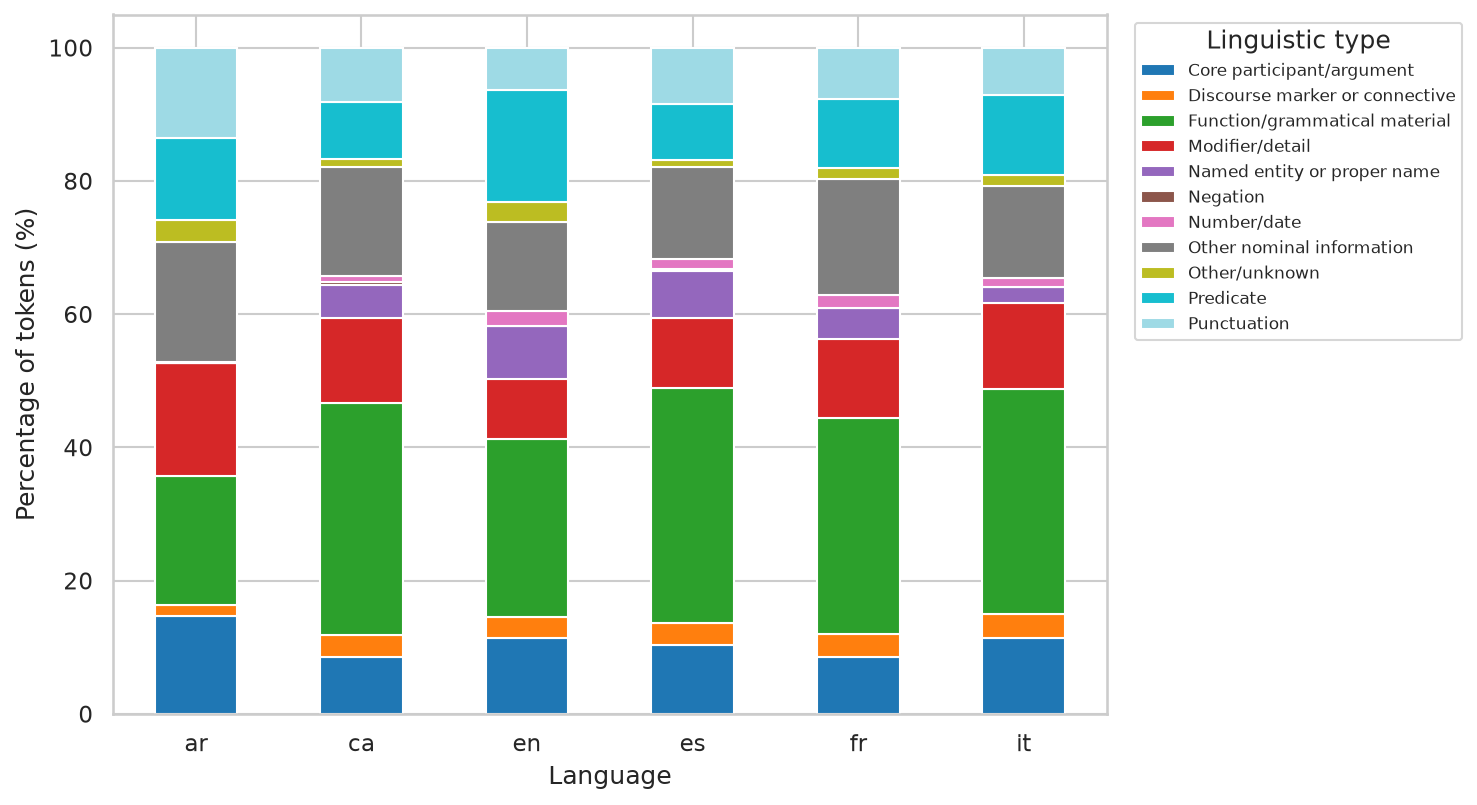

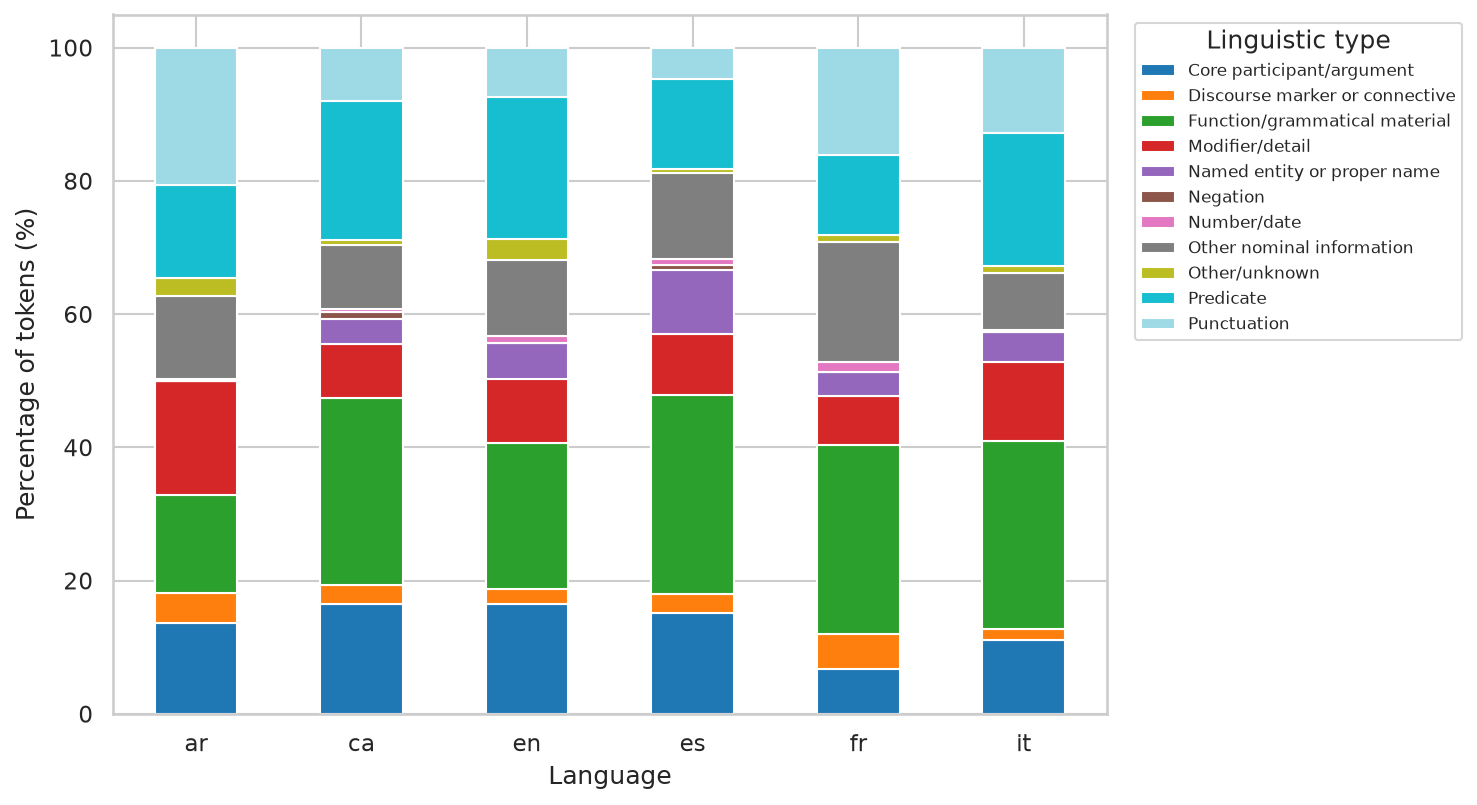

In [ ]:
# 13. Linguistic types of deleted and added material


# Operational taxonomy: strict precedence order (documented per the task)
#
# 1. Punctuation             -- UPOS == PUNCT
# 2. Number/date              -- UPOS == NUM
# 3. Named entity/proper name -- UPOS == PROPN
# 4. Negation                  -- morphology contains Polarity=Neg
# 5. Discourse marker/connective -- dep in {discourse, cc}
# 6. Predicate                 -- UPOS in {VERB, AUX}
# 7. Core participant/argument -- dep in {nsubj, nsubj:pass, csubj, csubj:pass, obj, iobj}
# 8. Other nominal information -- UPOS == NOUN
# 9. Modifier/detail           -- dep in {amod, advmod, nmod, acl, advcl, appos, nummod}
# 10. Function/grammatical material -- UPOS in {DET, ADP, CCONJ, SCONJ, PART, PRON}
# 11. Mixed span (span-level only, not token-level)
# 12. Other/unknown            -- fallback
#
# Rationale for ordering: more specific/informative categories are checked
# first (e.g. a PROPN that also happens to be a grammatical subject is
# classified as "Named entity", not "Core participant", since knowing WHAT
# was deleted matters more here than its grammatical role).

def classify_token(upos, dep, morph):
    morph = str(morph)
    if upos == "PUNCT":
        return "Punctuation"
    if upos == "NUM":
        return "Number/date"
    if upos == "PROPN":
        return "Named entity or proper name"
    if "Polarity=Neg" in morph:
        return "Negation"
    if dep in ("discourse", "cc"):
        return "Discourse marker or connective"
    if upos in ("VERB", "AUX"):
        return "Predicate"
    if dep in ("nsubj", "nsubj:pass", "csubj", "csubj:pass", "obj", "iobj"):
        return "Core participant/argument"
    if upos == "NOUN":
        return "Other nominal information"
    if dep in ("amod", "advmod", "nmod", "acl", "advcl", "appos", "nummod"):
        return "Modifier/detail"
    if upos in ("DET", "ADP", "CCONJ", "SCONJ", "PART", "PRON"):
        return "Function/grammatical material"
    return "Other/unknown"


# Apply classification to every DELETE/INSERT token

edit_tokens = derived_spacy_udpipe_tokens[derived_spacy_udpipe_tokens["operation"].isin(["DELETE", "INSERT"])].copy()
edit_tokens["linguistic_type"] = edit_tokens.apply(lambda r: classify_token(r["upos"], r["dep"], r["morph"]), axis=1)

deleted_tokens = edit_tokens[edit_tokens["operation"] == "DELETE"]
added_tokens = edit_tokens[edit_tokens["operation"] == "INSERT"]


# table_22 / table_23: token counts and percentages by linguistic type

def type_summary(df, label):
    counts = df["linguistic_type"].value_counts()
    pcts = df["linguistic_type"].value_counts(normalize=True) * 100
    overall = pd.DataFrame({"linguistic_type": counts.index, "n_tokens": counts.values, "pct": pcts.values, "language": "all"})

    by_lang = df.groupby(["language", "linguistic_type"]).size().rename("n_tokens").reset_index()
    by_lang["pct"] = by_lang.groupby("language")["n_tokens"].transform(lambda x: 100 * x / x.sum())

    result = pd.concat([overall, by_lang], ignore_index=True)
    return result

table_22 = type_summary(deleted_tokens, "deleted")
table_23 = type_summary(added_tokens, "added")
table_22.to_csv(TABLES_DIR / "table_22_deleted_material_types.csv", index=False)
table_23.to_csv(TABLES_DIR / "table_23_added_material_types.csv", index=False)

print("=== table_22: deleted material types (overall) ===")
print(table_22[table_22["language"] == "all"].sort_values("n_tokens", ascending=False).to_string(index=False))
print()
print("=== table_23: added material types (overall) ===")
print(table_23[table_23["language"] == "all"].sort_values("n_tokens", ascending=False).to_string(index=False))


# Span-level classification: majority type per span, or "Mixed span"
# if the span's tokens don't share a single dominant category, joined
# from the spans built in Section 11

span_token_types = edit_tokens.merge(
    derived_spans[["pair_id", "side", "operation", "start_index", "end_index", "span_length"]],
    on=["pair_id", "side", "operation"], how="inner"
)
span_token_types = span_token_types[
    (span_token_types["token_index"] >= span_token_types["start_index"]) &
    (span_token_types["token_index"] <= span_token_types["end_index"])
]

span_types = span_token_types.groupby(["pair_id", "side", "operation", "start_index", "end_index"])["linguistic_type"].apply(
    lambda types: types.iloc[0] if types.nunique() == 1 else "Mixed span"
).rename("span_linguistic_type").reset_index()

derived_spans_typed = derived_spans.merge(span_types, on=["pair_id", "side", "operation", "start_index", "end_index"], how="left")


# table_24: span counts, percentages, and median/IQR length by linguistic type

rows = []
for op in ["DELETE", "INSERT"]:
    op_spans = derived_spans_typed[derived_spans_typed["operation"] == op]
    for ling_type, group in op_spans.groupby("span_linguistic_type"):
        rows.append({
            "operation": op, "linguistic_type": ling_type, "n_spans": len(group),
            "pct_of_spans": 100 * len(group) / len(op_spans),
            "median_length": group["span_length"].median(),
            "q1_length": group["span_length"].quantile(0.25),
            "q3_length": group["span_length"].quantile(0.75),
            "iqr_length": group["span_length"].quantile(0.75) - group["span_length"].quantile(0.25),
        })
table_24 = pd.DataFrame(rows)
table_24.to_csv(TABLES_DIR / "table_24_edit_type_span_statistics.csv", index=False)

print()
print("=== table_24: span statistics by linguistic type ===")
print(table_24.sort_values(["operation", "n_spans"], ascending=[True, False]).to_string(index=False))


# Representative examples (fixed random seed)

examples_rows = []
for op in ["DELETE", "INSERT"]:
    op_spans = derived_spans_typed[derived_spans_typed["operation"] == op]
    for ling_type, group in op_spans.groupby("span_linguistic_type"):
        sample = group.sample(n=min(3, len(group)), random_state=RANDOM_SEED)
        examples_rows.append(sample)
examples_df = pd.concat(examples_rows, ignore_index=True)
examples_df = examples_df.merge(pairs[["pair_id", "source_text", "target_text"]], on="pair_id", how="left")
examples_df[["pair_id", "language", "operation", "span_linguistic_type", "span_text", "span_length", "source_text", "target_text"]].to_csv(
    TABLES_DIR.parent / "examples_deletion_addition_types.csv", index=False
)

print()
print(f"Saved {len(examples_df)} representative examples.")


# figure_18 / figure_19: type distribution by language

for op, fig_name in [("DELETE", "figure_18_deleted_types_by_language"), ("INSERT", "figure_19_added_types_by_language")]:
    op_df = edit_tokens[edit_tokens["operation"] == op]
    type_pct = pd.crosstab(op_df["language"], op_df["linguistic_type"], normalize="index") * 100
    fig, ax = plt.subplots(figsize=(10, 5.5))
    type_pct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_xlabel("Language")
    ax.set_ylabel("Percentage of tokens (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Linguistic type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{fig_name}.pdf")
    fig.savefig(FIGURES_DIR / f"{fig_name}.png", dpi=300)
    plt.show()

## Detailed deletion questions

Investigate whether simplification deletes:

- modifiers and descriptive detail;
- discourse markers;
- function words;
- subjects, objects or other arguments;
- predicates or subordinate clauses;
- named entities, numbers or dates;
- negation.

Flag potentially meaning-changing deletions, especially deletion of negation, predicates, core arguments, named entities and quantities. This is a descriptive warning, not an automatic quality judgement.

**Intern response:**
* Yes, modifiers/descriptive detail get deleted, 12.6% of all deletions fall into this category. This is one of the more expected simplification deletions

* Yes, discourse markers get deleted, but less often — 3.1% of deletions

* Function words are by far the most deleted category; 31.6% of all deletions. This is the single biggest thing being removed

* Yes, subjects/objects/other arguments get deleted; 10.9% of deletions are core participants. Flagging this as potentially meaning-changing

* Yes, predicates get deleted too; 10.5% of deletions. Also flagging as potentially meaning-changing

* Named entities and numbers/dates are deleted less often — 4.2% named entities, 1.2% numbers/dates

* Negation deletion is rare, only 0.2% of deletions

* Flagging as potentially meaning-changing: core participant deletion (10.9%) and predicate deletion (10.5%) together make up over a fifth of all deletions; removing a subject/object or main verb can change what a sentence asserts, not just how it reads. Named entity deletion (4.2%) also changes factual content, not just readability. Negation deletion, while rare (0.2%), deserves individual review given how severely it can reverse meaning even in a small number of cases. This is a descriptive flag, not a quality judgement

## Detailed addition questions

Investigate whether simplification adds:

- explanatory nominal material;
- discourse connectives;
- explicit subjects or arguments;
- punctuation or sentence-boundary material;
- function words needed after restructuring;
- names, numbers or examples;
- negation.

Separate substantive additions from punctuation-only additions. Identify whether inserted spans tend to be short grammatical repairs or longer possible explanations.

**Intern response:**
* Yes, explanatory nominal material gets added. 10.7% of additions are nominal content (nouns), often serving this role

* Yes, discourse connectives get added, but modestly 2.7% of additions

* Yes, explicit subjects/arguments get added. 13.6% of additions are core participants, higher than the 10.9% seen on the deletion side, suggesting simplification sometimes makes implicit arguments explicit

* Yes, punctuation/sentence-boundary material is added; 9.9% of additions, likely from sentence splitting

* Function words dominate additions; 28.0%, likely a knock-on effect of restructuring (splits/merges need new determiners/prepositions to stay grammatical)

* Names/numbers/examples are added too; 5.1% named entities, 0.6% numbers/dates

* Negation addition is rare, 0.5% of additions

* Separating substantive vs. punctuation-only: 9.9% of additions are pure punctuation, so roughly 90% represent genuine content additions, not just re-punctuating

* Short repairs vs. longer explanations: every single-category type has a median span length of just 1 token; Function/grammatical material, Predicate, Core participant, Modifier/detail, all identical at median 1. The only spans that run longer are "Mixed span" (median 3 tokens) - meaning genuinely longer insertions tend to combine multiple linguistic types together (e.g. a function word plus a noun plus a modifier in one go), rather than any single category (like "explanation") being systematically longer on its own. So additions are overwhelmingly short single-token repairs; longer, more explanation-like insertions are the compositionally mixed exception, not the rule

# 14. Broader linguistic complexity profile: complex versus simple

Calculate language-internal paired features using the same annotation system.

## Mandatory universal features

- token count;
- character count;
- mean token length;
- content-token count and lexical density;
- number of unique lemmas and a length-aware lexical-diversity measure;
- verb count;
- finite-verb count where morphology permits;
- estimated clause count;
- subordinate-clause count and rate;
- dependency-tree depth;
- mean and maximum dependency distance;
- punctuation count;
- named-entity count;
- number count;
- negation count.

Use caution with cross-language comparability and document all heuristics.

## Outputs

For every language and side, report median, Q1, Q3 and IQR for every feature.

Save:

- `table_25_linguistic_features_iqr_by_language_and_side.csv`
- `table_26_paired_linguistic_change_by_language.csv`
- `figure_20_linguistic_change_effect_sizes.pdf` and `.png`

Use paired tests, effect sizes, confidence intervals and Holm correction. The effect-size figure should show direction and uncertainty, not only p-values.

Computed 19 features for 1930 pairs.

=== table_25 (sample) ===
language    side           feature    median        q1         q3       iqr
      ar complex          n_tokens 18.000000 12.000000  28.000000 16.000000
      ar complex        char_count 68.000000 45.500000 107.500000 62.000000
      ar complex mean_token_length  3.857143  3.596296   4.162281  0.565984
      ar complex  n_content_tokens  8.000000  5.000000  12.000000  7.000000
      ar complex   lexical_density  0.434783  0.352397   0.533333  0.180937
      ar complex   n_unique_lemmas 16.000000 11.000000  26.000000 15.000000
      ar complex lexical_diversity  3.880570  3.316625   4.797916  1.481291
      ar complex           n_verbs  2.000000  1.000000   3.500000  2.500000
      ar complex    n_finite_verbs  1.000000  0.000000   1.000000  1.000000
      ar complex         n_clauses  2.000000  1.000000   3.000000  2.000000

=== table_26 (sample) ===
language           feature  median_diff      p_value  effect_size_r      

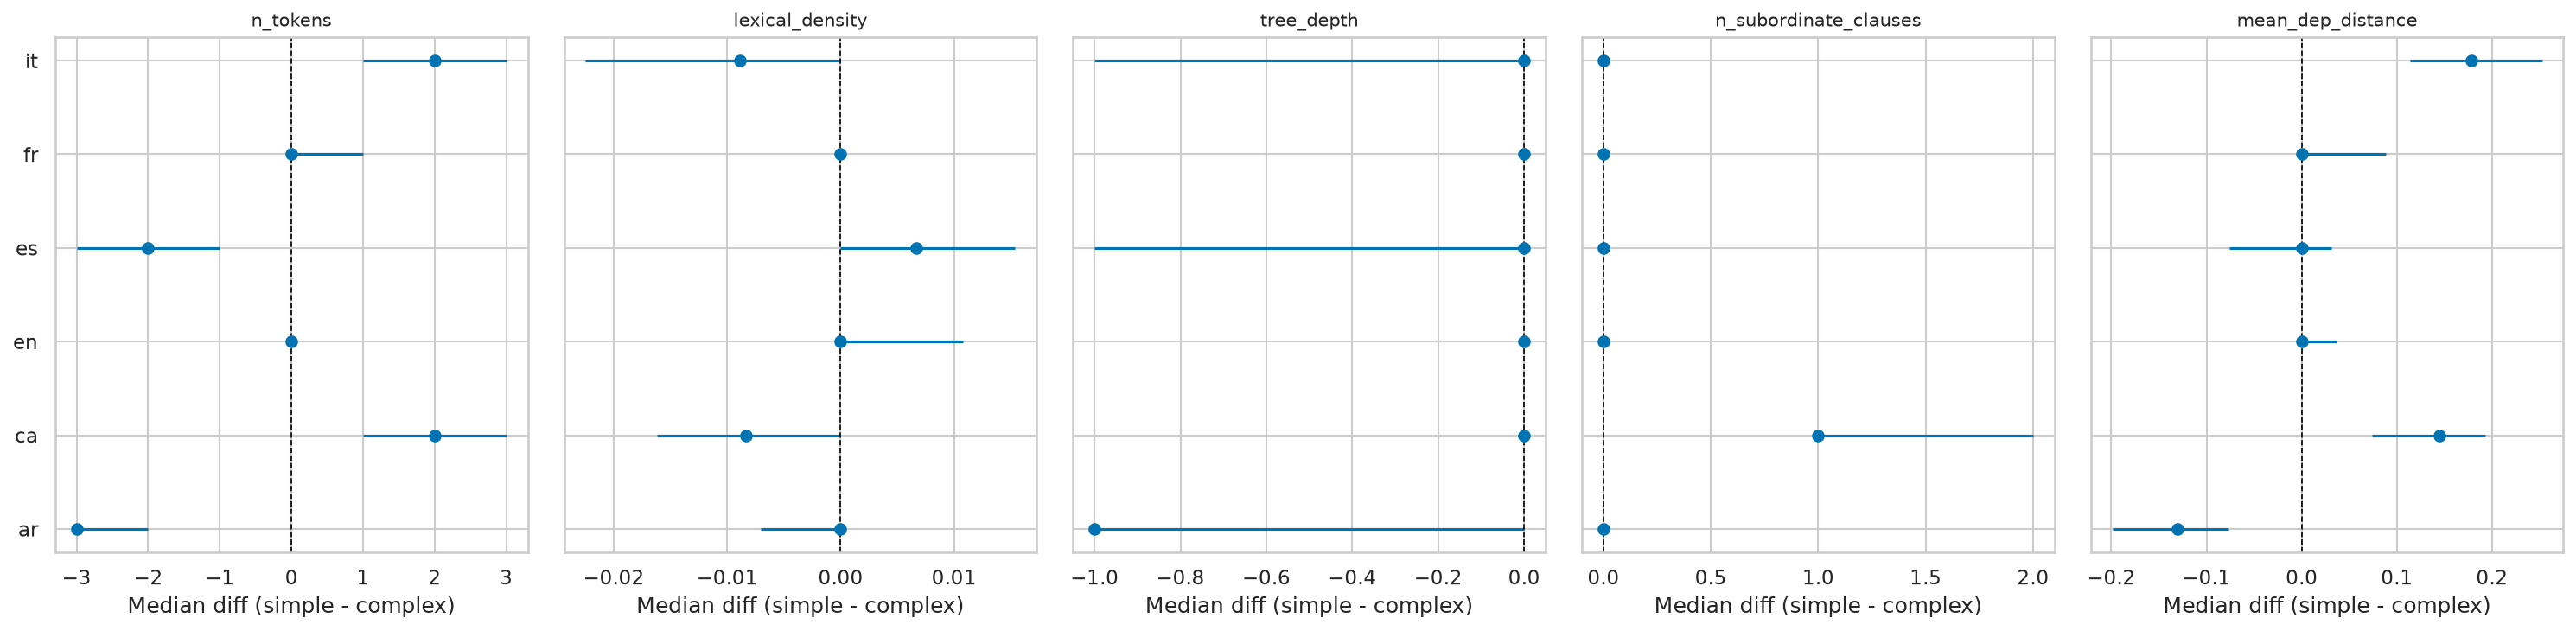

In [35]:
# 14. Broader linguistic complexity profile: complex versus simple

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


# Per pair x side linguistic feature computation

CONTENT_UPOS = {"NOUN", "VERB", "PROPN", "ADJ", "ADV"}
SUBORDINATE_DEPS = {"advcl", "acl", "ccomp", "xcomp", "csubj"}

def compute_features(group):
    n_tokens = len(group)
    char_count = group["text"].str.len().sum()
    mean_token_len = group["text"].str.len().mean()
    n_content = group["upos"].isin(CONTENT_UPOS).sum()
    lexical_density = n_content / n_tokens if n_tokens else np.nan
    n_unique_lemmas = group["lemma"].nunique()
    # Length-aware lexical diversity (Guiraud's R: unique lemmas / sqrt(N)),
    # chosen because raw type-token ratio is highly sensitive to sentence length
    lexical_diversity = n_unique_lemmas / np.sqrt(n_tokens) if n_tokens else np.nan
    n_verbs = (group["upos"] == "VERB").sum()
    n_finite_verbs = ((group["upos"] == "VERB") & (group["morph"].str.contains("VerbForm=Fin", na=False))).sum()
    n_subordinate = group["dep"].isin(SUBORDINATE_DEPS).sum()
    subordinate_rate = n_subordinate / n_tokens if n_tokens else np.nan
    # Estimated clause count: 1 main clause + each subordinate-clause marker found
    n_clauses = 1 + n_subordinate

    # Dependency-tree depth: longest path from any token up to the root
    head_map = dict(zip(group["token_index"], group["head_i"]))
    depths = []
    for idx in group["token_index"]:
        depth, cur, visited = 0, idx, set()
        while cur in head_map and head_map[cur] != cur and cur not in visited and depth < 100:
            visited.add(cur)
            cur = head_map[cur]
            depth += 1
        depths.append(depth)
    tree_depth = max(depths) if depths else 0

    dep_distances = (group["token_index"] - group["head_i"]).abs()
    mean_dep_distance = dep_distances.mean()
    max_dep_distance = dep_distances.max()

    n_punct = (group["upos"] == "PUNCT").sum()
    n_named_entities = (group["upos"] == "PROPN").sum()
    n_numbers = (group["upos"] == "NUM").sum()
    n_negations = group["morph"].str.contains("Polarity=Neg", na=False).sum()

    return pd.Series({
        "n_tokens": n_tokens, "char_count": char_count, "mean_token_length": mean_token_len,
        "n_content_tokens": n_content, "lexical_density": lexical_density,
        "n_unique_lemmas": n_unique_lemmas, "lexical_diversity": lexical_diversity,
        "n_verbs": n_verbs, "n_finite_verbs": n_finite_verbs,
        "n_clauses": n_clauses, "n_subordinate_clauses": n_subordinate, "subordinate_rate": subordinate_rate,
        "tree_depth": tree_depth, "mean_dep_distance": mean_dep_distance, "max_dep_distance": max_dep_distance,
        "n_punct": n_punct, "n_named_entities": n_named_entities, "n_numbers": n_numbers, "n_negations": n_negations,
    })

FEATURE_COLS = [
    "n_tokens", "char_count", "mean_token_length", "n_content_tokens", "lexical_density",
    "n_unique_lemmas", "lexical_diversity", "n_verbs", "n_finite_verbs", "n_clauses",
    "n_subordinate_clauses", "subordinate_rate", "tree_depth", "mean_dep_distance",
    "max_dep_distance", "n_punct", "n_named_entities", "n_numbers", "n_negations",
]

linguistic_features = derived_spacy_udpipe_tokens.groupby(["pair_id", "language", "side"]).apply(
    compute_features, include_groups=False
).reset_index()

print(f"Computed {len(FEATURE_COLS)} features for {linguistic_features['pair_id'].nunique()} pairs.")


# table_25: IQR by language and side, for every feature

rows_25 = []
for (lang, side), group in linguistic_features.groupby(["language", "side"]):
    for feat in FEATURE_COLS:
        s = group[feat]
        rows_25.append({
            "language": lang, "side": side, "feature": feat,
            "median": s.median(), "q1": s.quantile(0.25), "q3": s.quantile(0.75),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
        })
table_25 = pd.DataFrame(rows_25)
table_25.to_csv(TABLES_DIR / "table_25_linguistic_features_iqr_by_language_and_side.csv", index=False)

print()
print("=== table_25 (sample) ===")
print(table_25.head(10).to_string(index=False))


# table_26: paired change by language, Wilcoxon + effect size + Holm correction
# (Holm correction applied within each language, across its own features --
# treating each language's feature battery as one family of tests)

rows_26 = []
for lang, lang_df in linguistic_features.groupby("language"):
    lang_wide = lang_df.pivot(index="pair_id", columns="side", values=FEATURE_COLS)
    for feat in FEATURE_COLS:
        complex_vals = lang_wide[(feat, "complex")].values
        simple_vals = lang_wide[(feat, "simple")].values
        diff = simple_vals - complex_vals
        if np.all(diff == 0):
            rows_26.append({"language": lang, "feature": feat, "median_diff": 0, "p_value": 1.0, "effect_size_r": 0.0})
            continue
        try:
            stat, p = wilcoxon(complex_vals, simple_vals, zero_method="wilcox")
        except ValueError:
            stat, p = np.nan, 1.0
        n_nonzero = int((diff != 0).sum())
        if n_nonzero > 0 and not np.isnan(stat):
            mean_w = n_nonzero * (n_nonzero + 1) / 4
            std_w = np.sqrt(n_nonzero * (n_nonzero + 1) * (2 * n_nonzero + 1) / 24)
            z = (stat - mean_w) / std_w if std_w > 0 else 0
            r = z / np.sqrt(n_nonzero)
        else:
            r = 0.0
        rows_26.append({"language": lang, "feature": feat, "median_diff": np.median(diff), "p_value": p, "effect_size_r": r})

table_26 = pd.DataFrame(rows_26)
table_26["p_holm"] = np.nan
for lang, idx in table_26.groupby("language").groups.items():
    _, p_holm, _, _ = multipletests(table_26.loc[idx, "p_value"], method="holm")
    table_26.loc[idx, "p_holm"] = p_holm
table_26["significant_holm"] = table_26["p_holm"] < 0.05

table_26.to_csv(TABLES_DIR / "table_26_paired_linguistic_change_by_language.csv", index=False)

print()
print("=== table_26 (sample) ===")
print(table_26.head(10).to_string(index=False))


# figure_20: effect sizes with direction and uncertainty, not just p-values

# 95% CI for effect size via bootstrap over pairs, per language x feature
def bootstrap_effect_ci(complex_vals, simple_vals, n_boot=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = len(complex_vals)
    boot_diffs = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        boot_diffs.append(np.median(simple_vals[idx] - complex_vals[idx]))
    return np.percentile(boot_diffs, [2.5, 97.5])

ci_rows = []
for lang, lang_df in linguistic_features.groupby("language"):
    lang_wide = lang_df.pivot(index="pair_id", columns="side", values=FEATURE_COLS)
    for feat in FEATURE_COLS:
        complex_vals = lang_wide[(feat, "complex")].values
        simple_vals = lang_wide[(feat, "simple")].values
        ci_low, ci_high = bootstrap_effect_ci(complex_vals, simple_vals)
        ci_rows.append({"language": lang, "feature": feat, "ci_low": ci_low, "ci_high": ci_high})
ci_df = pd.DataFrame(ci_rows)
table_26_plot = table_26.merge(ci_df, on=["language", "feature"], how="left")

# Plot a focused subset of the most interpretable features (all 19 x 6 languages would be unreadable)
key_features = ["n_tokens", "lexical_density", "tree_depth", "n_subordinate_clauses", "mean_dep_distance"]
plot_df = table_26_plot[table_26_plot["feature"].isin(key_features)]

fig, axes = plt.subplots(1, len(key_features), figsize=(4 * len(key_features), 5), sharey=True)
for ax, feat in zip(axes, key_features):
    sub = plot_df[plot_df["feature"] == feat].sort_values("language")
    ax.errorbar(
        sub["median_diff"], range(len(sub)),
        xerr=[sub["median_diff"] - sub["ci_low"], sub["ci_high"] - sub["median_diff"]],
        fmt="o", color=sns.color_palette("colorblind")[0],
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["language"])
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("Median diff (simple - complex)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_20_linguistic_change_effect_sizes.pdf")
fig.savefig(FIGURES_DIR / "figure_20_linguistic_change_effect_sizes.png", dpi=300)
plt.show()

# 15. Strategy annotation import and validation

The current processed alignment files do not contain strategy labels. Use either the supplied project annotations or complete `strategy_annotations_template.csv`.

## Required macro-strategy columns

- `Omission`
- `Compression`
- `Explanation`
- `Syntactic_Changes`
- `Substitution`
- `Transposition`
- `Modulation`
- `Transcription`

Values must be binary: 1 = present, 0 = absent. Retain an `annotation_status`, `annotator_id` and `notes` field where available.

## Validation

Check:

- unique `pair_id`;
- coverage of pair IDs in both files;
- binary values only;
- missing or unresolved labels;
- annotation coverage by language and collection;
- label cardinality per pair;
- pairs with no strategy label;
- pairs with multiple strategy labels;
- inter-annotator agreement when more than one annotation is available.

Do not interpret blank cells as zero unless the annotation protocol explicitly says that blanks mean absence.

Save:

- `table_27_strategy_annotation_coverage.csv`
- `table_28_strategy_annotation_quality.csv`

In [36]:
# 15. Strategy annotation import and validation

STRATEGY_COLS = ["Omission", "Compression", "Explanation", "Syntactic_Changes", "Substitution", "Transposition", "Modulation", "Transcription"]


# Validation checks

checks = []
checks.append({"check": "unique_pair_id", "result": pairs["pair_id"].is_unique})
checks.append({"check": "pair_id_coverage_in_template", "result": pairs["pair_id"].notna().all()})

for col in STRATEGY_COLS:
    non_null = pairs[col].dropna()
    bad_values = set(non_null.unique()) - {0, 1, 0.0, 1.0}
    checks.append({
        "check": f"{col}_binary_values_only",
        "result": len(bad_values) == 0,
        "bad_values": str(bad_values) if bad_values else None,
    })

table_28 = pd.DataFrame(checks)
table_28.to_csv(TABLES_DIR / "table_28_strategy_annotation_quality.csv", index=False)

print("=== table_28: strategy annotation quality checks ===")
print(table_28.to_string(index=False))


# Coverage by language and collection
# IMPORTANT: blank strategy cells are NOT treated as "no strategy" here --
# only annotation_status determines whether a pair has been labelled at all.

pairs["is_annotated"] = pairs["annotation_status"] != "unannotated"

coverage_by_lang = pairs.groupby("language")["is_annotated"].agg(["sum", "count"]).rename(columns={"sum": "n_annotated", "count": "n_total"})
coverage_by_lang["pct_annotated"] = 100 * coverage_by_lang["n_annotated"] / coverage_by_lang["n_total"]

coverage_by_collection = pairs.groupby("collection")["is_annotated"].agg(["sum", "count"]).rename(columns={"sum": "n_annotated", "count": "n_total"})
coverage_by_collection["pct_annotated"] = 100 * coverage_by_collection["n_annotated"] / coverage_by_collection["n_total"]

table_27 = pd.concat([
    coverage_by_lang.reset_index().rename(columns={"language": "group"}).assign(dimension="language"),
    coverage_by_collection.reset_index().rename(columns={"collection": "group"}).assign(dimension="collection"),
], ignore_index=True)
table_27.to_csv(TABLES_DIR / "table_27_strategy_annotation_coverage.csv", index=False)

print()
print("=== table_27: annotation coverage by language ===")
print(coverage_by_lang)


# Label cardinality per pair

pairs["n_strategies_labelled"] = pairs[STRATEGY_COLS].sum(axis=1, skipna=True)
n_no_label = (pairs["n_strategies_labelled"] == 0).sum()
n_multi_label = (pairs["n_strategies_labelled"] > 1).sum()

print()
print("Label cardinality distribution:")
print(pairs["n_strategies_labelled"].value_counts(dropna=False).sort_index())
print()
print(f"Pairs with no strategy label: {n_no_label} ({100*n_no_label/len(pairs):.2f}%)")
print(f"Pairs with multiple strategy labels: {n_multi_label} ({100*n_multi_label/len(pairs):.2f}%)")
print(f"Overall annotation coverage: {100*pairs['is_annotated'].mean():.2f}%")


# Inter-annotator agreement: not computable -- no independently annotated
# overlap exists yet, since 0% of pairs have any annotation at all

if pairs["is_annotated"].sum() == 0:
    print()
    print("WARNING: 0% of pairs are currently annotated (annotation_status == 'unannotated' for all 1,930 pairs).")
    print("Section 16 (strategy statistics) cannot be meaningfully run until real strategy labels exist.")
    print("This applies to BOTH the processed pairs_with_splits.csv AND the raw strategy_annotations_template.csv --")
    print("this is a genuine data-state gap, not an artefact of the processing pipeline.")

=== table_28: strategy annotation quality checks ===
                               check  result  bad_values
                      unique_pair_id    True         NaN
        pair_id_coverage_in_template    True         NaN
         Omission_binary_values_only    True         NaN
      Compression_binary_values_only    True         NaN
      Explanation_binary_values_only    True         NaN
Syntactic_Changes_binary_values_only    True         NaN
     Substitution_binary_values_only    True         NaN
    Transposition_binary_values_only    True         NaN
       Modulation_binary_values_only    True         NaN
    Transcription_binary_values_only    True         NaN

=== table_27: annotation coverage by language ===
          n_annotated  n_total  pct_annotated
language                                     
ar                  0      399            0.0
ca                  0      380            0.0
en                  0      188            0.0
es                  0      362         

# 16. Simplification-strategy statistics

## Frequency and distribution

Report:

- support and prevalence of each strategy overall;
- support and prevalence by language and collection;
- median, Q1, Q3 and IQR number of strategies per pair;
- percentage of single-label and multi-label pairs;
- most frequent exact strategy combinations;
- label cardinality and label density.

## Co-occurrence

Calculate:

- pairwise co-occurrence counts;
- Jaccard similarity;
- phi coefficient or another justified binary association;
- corrected significance tests where inferential results are shown.

Produce:

- `table_29_strategy_frequency.csv`
- `table_30_strategy_frequency_by_language.csv`
- `table_31_strategy_combinations.csv`
- `table_32_strategy_cooccurrence.csv`
- `figure_21_strategy_support.pdf` and `.png`
- `figure_22_strategy_cooccurrence.pdf` and `.png`
- `figure_23_strategy_combinations_upset.pdf` and `.png`

Use an UpSet plot rather than a Venn diagram for eight multi-label strategies.

## Strategy-distribution questions

- Which strategies are dominant or rare?
- Do label distributions differ substantially by language or collection?
- Which strategies usually appear together?
- Are any language-level strategy results too sparse for reliable inference?
- Does one collection dominate a strategy and therefore confound a language comparison?

**Intern response:**

# 17. Link observed edit signatures to annotated strategies

## Pair-level edit-signature features

Construct one row per sentence pair containing:

- deletion token rate and deletion span count;
- insertion token rate and insertion span count;
- substitution rate;
- split, merge and complex-operation rates;
- reordering rate;
- content edit rate;
- length reduction rate;
- mean and maximum deletion span length;
- mean and maximum insertion span length;
- proportions of linguistic deletion/addition types;
- source length, alignment coverage, language, collection and document.

## Descriptive strategy profiles

For every strategy, compare strategy-present versus strategy-absent pairs. Report:

- N;
- mean and standard deviation;
- median, Q1, Q3 and IQR;
- difference in medians with bootstrap confidence interval;
- suitable effect size.

Save:

- `table_33_edit_signature_by_strategy.csv`
- `figure_24_edit_signature_strategy_heatmap.pdf` and `.png`

## Hypothesis-led associations

Evaluate the following as hypotheses, not assumed truths:

| Strategy | Expected alignment/edit evidence |
|---|---|
| Omission | More deleted content and deletion spans |
| Compression | Length reduction, deletion, merge and denser rewriting |
| Explanation | More substantive insertions and longer insertion spans |
| Syntactic Changes | Split, merge, reordering and syntactic-feature changes |
| Substitution | More one-to-one substitutions |
| Transposition | More reordering/crossing-link evidence |
| Modulation | May involve substitution or complex rewrites, but alignment alone is insufficient |
| Transcription | Surface-form substitution, especially names or representations, but requires linguistic inspection |

For each strategy:

1. test each pre-specified association;
2. correct for multiple comparisons;
3. report effect sizes and uncertainty;
4. inspect whether the effect remains after controlling for source length, language and collection;
5. explicitly report unsupported hypotheses.

Save:

- `table_34_strategy_edit_association_tests.csv`

## Multivariable analysis

Fit an interpretable binary model for each sufficiently supported strategy:

`strategy_present ~ edit_signature_features + source_length + alignment_coverage + language + collection`

Use regularised logistic regression or a justified generalised linear model. Prevent leakage and unstable estimates:

- standardise continuous predictors;
- check collinearity;
- use grouped or stratified cross-validation;
- avoid fitting a model when positive support is too small;
- report cross-validated AUROC and average precision;
- report coefficients or odds ratios with uncertainty;
- perform sensitivity analysis excluding low-alignment-coverage pairs.

This analysis asks whether a strategy has a distinctive observable edit signature. It does **not** replace human strategy annotation.

Save:

- `table_35_strategy_edit_models.csv`
- `figure_25_strategy_model_coefficients.pdf` and `.png`

# 18. Edit-operation and strategy interaction profiles

Go beyond one operation at a time.

## Task

Define transparent pair-level edit profiles such as:

- deletion-dominant;
- insertion-dominant;
- substitution-dominant;
- structural: split/merge/reordering;
- mixed/high-density;
- low-edit/near-copy.

Use documented thresholds based on the data distribution, or use an interpretable clustering method followed by manual validation.

Analyse:

- profile frequency by language;
- strategy prevalence within each profile;
- profile purity and entropy;
- examples nearest each profile centre.

Produce:

- `table_36_edit_profiles.csv`
- `table_37_strategy_by_edit_profile.csv`
- `figure_26_edit_profiles_by_language.pdf` and `.png`

# 19. Methodological robustness and XAI stratification

These checks are part of Stage 1 because they determine whether the
later explainability results can be interpreted fairly.

## A. Stratification variables

Create quartile or principled bands for:

- source length;
- content edit rate;
- source and target alignment coverage;
- deletion rate;
- insertion rate;
- number of annotated strategies, when available.

Save the boundaries and support in
`table_38_xai_stratification_bands.csv`.

## B. Document-aware uncertainty

Sentence pairs from the same document are not fully independent.
Where a language contains multiple documents, calculate cluster-bootstrap
confidence intervals by resampling documents and then retaining their
sentence pairs.

Where a language contains only one document, do not present a
document-cluster interval. Report the limitation explicitly.

## C. Adjusted language comparisons

Use a robust regression or another justified pair-level model to test
whether language differences in length reduction or edit rate remain
after accounting for:

- source sentence length;
- alignment coverage;
- collection, where estimable.

Do not interpret these models causally.

## D. Joint edit-profile comparison

Compare the complete pair-level operation vector across languages using
a multivariate permutation procedure or another justified robust method.
This complements, rather than replaces, operation-by-operation summaries.

## E. Alignment sensitivity

Repeat the main descriptive and association results using at least one
pre-declared high-coverage condition, for example source and target
coverage of at least 0.70. Compare the direction and magnitude of the
results with the full dataset.

## F. Reporting thresholds and examples

Establish minimum support for operation-specific and strategy-specific
reporting. Select reproducible examples of:

- common edit patterns;
- rare operations;
- expected edit–strategy relationships;
- counter-examples;
- low-coverage cases.

Save:

- `table_39_support_and_reporting_thresholds.csv`
- `examples_edit_strategy_cases.csv`

# 20. Revised explainability-readiness conclusions

The final recommendations must now address:

1. primary and secondary edit masks;
2. treatment of target insertions, which cannot be scored directly by a source-only classifier attribution without an adapted evaluation;
3. whether deletion-only, insertion-only and mixed pairs should be reported separately;
4. minimum alignment coverage for sensitivity analysis;
5. minimum support for operation- and strategy-level reporting;
6. language-macro and overall-micro averaging;
7. edit-density, sentence-length and strategy-cardinality strata;
8. limitations of using observed edits as plausibility evidence;
9. which strategies are structurally observable and which require semantic analysis;
10. whether a second target-side or pair-input explanation setup is needed to evaluate additions and Explanation.

**Intern recommendations:**

# 21. Consolidated explainability-readiness recommendations

Based on the statistical results, recommend:

1. the primary and secondary human-edit masks;
2. any minimum alignment-coverage sensitivity condition;
3. the minimum operation support required for operation-specific reporting;
4. stratification variables for attribution evaluation;
5. the metrics that should be reported overall and per language;
6. warnings that should appear in the paper.

Do not change the dataset in this task. Recommendations for exclusions must be reported as sensitivity analyses rather than silently applied.

**Intern recommendations:**

# 22. Final summary tables and written report

Create two compact summary tables.

## A. Dataset and complex-versus-simple summary

Include:

- pairs, documents and source tokens;
- languages and collections;
- complex and simple median, Q1, Q3 and IQR by language;
- paired length reduction;
- alignment coverage;
- overall content edit rate;
- train/validation/test counts.

Save:

- `table_40_key_dataset_statistics.csv`
- `table_40_key_dataset_statistics.tex`

## B. Strategy and edit summary

Include:

- support and prevalence of every strategy;
- dominant deletion and addition types;
- strongest supported edit-strategy associations;
- rare operations or strategies that should not receive standalone XAI claims;
- proposed sensitivity thresholds.

Save:

- `table_41_key_strategy_edit_statistics.csv`
- `table_41_key_strategy_edit_statistics.tex`

## Written report

Write an 800–1,200 word results summary covering:

- dataset composition;
- exact complex-versus-simple quartile and IQR findings;
- alignment quality;
- deletion and addition span characteristics;
- linguistic types of deleted and added material;
- simplification-strategy frequency and co-occurrence;
- edit-strategy associations and counter-examples;
- cross-language and collection variation;
- implications and limitations for the explainability experiments.

Every numerical claim must point to a table, figure or model result.

## Final written summary

**Intern response:**

# 23. Reproducibility checklist

Before submission, confirm all of the following:

- [ ] The notebook runs from top to bottom.
- [ ] No original data file was modified.
- [ ] Every table was saved as CSV.
- [ ] The key summary table was also saved as LaTeX.
- [ ] Every figure was saved as PDF and 300 dpi PNG.
- [ ] Random seeds were fixed where resampling was used.
- [ ] Statistical tests report sample size, test statistic, adjusted p-value, effect size and confidence interval where applicable.
- [ ] Pair-level dependence was respected.
- [ ] Missing values and exclusions were reported.
- [ ] Figures have readable labels and no embedded titles.
- [ ] Interpretations distinguish evidence from speculation.
- [ ] The final notebook contains no unexplained warning or failed cell.